# Trajectory Comparison Analysis

This notebook compares reasoning trajectories that share the same structural choices across different personas and random seeds.

In [287]:
# Cell 1: Setup
import pandas as pd

# Set display options
pd.set_option('display.max_colwidth', 150)
pd.set_option('display.max_rows', 50)

In [288]:
# Cell 2: Load data
df = pd.read_csv('explainability_experiment/explainability_persona_all_results.csv')

print(f"Total trajectories: {len(df)}")
print(f"Personas: {sorted(df['persona_name'].unique())}")
print(f"Seeds: {sorted(df['seed'].unique())}")
print(f"Topics: {df['topic'].nunique()}")

Total trajectories: 750
Personas: ['agreeableness', 'conscientiousness', 'extraversion', 'neuroticism', 'openness']
Seeds: [np.int64(42), np.int64(123), np.int64(456)]
Topics: 1


In [289]:
# Cell 3: Create structure signature
df['structure_signature'] = (
	df['step_1_structure'].fillna('') + ' → ' +
	df['step_2_structure'].fillna('') + ' → ' +
	df['step_3_structure'].fillna('')
)

signature_counts = df['structure_signature'].value_counts()
print(f"Unique structure signatures: {len(signature_counts)}")
print("\nTop 10 most common signatures:")
for idx, (sig, count) in enumerate(signature_counts.head(10).items(), 1):
	print(f"{idx}. {sig} ({count} trajectories)")

Unique structure signatures: 748

Top 10 most common signatures:
1. emphasis_and_evaluation_cost_benefit_and_impact_analysis → concession_and_contrast_stakeholder_responsibility → addition_and_elaboration_feasibility_and_implementation (2 trajectories)
2. emphasis_and_evaluation_cost_benefit_and_impact_analysis → sequence_and_transition_risk_and_unintended_consequences → emphasis_and_evaluation_feasibility_and_implementation (2 trajectories)
3. exemplification_precedent_and_long_term_effects → addition_and_elaboration_incentives_and_power_dynamics → clarification_and_specification_incentives_and_power_dynamics (1 trajectories)
4. evidence_and_authority_ethical_principles → emphasis_and_evaluation_risk_and_unintended_consequences → concession_and_contrast_cost_benefit_and_impact_analysis (1 trajectories)
5. emphasis_and_evaluation_incentives_and_power_dynamics → sequence_and_transition_cost_benefit_and_impact_analysis → emphasis_and_evaluation_cost_benefit_and_impact_analysis (1 traject

In [290]:
# Cell 4: Select signature and create comparison table
# Use most common signature
selected_signature = signature_counts.index[0]
print(f"Selected signature: {selected_signature}")

subset = df[df['structure_signature'] == selected_signature].copy()
print(f"Trajectories with this signature: {len(subset)}")

# Create comparison table
comparison_df = subset[[
	'persona_name',
	'seed',
	'topic',
	'stance',
	'step_1_reasoning',
	'step_2_reasoning',
	'step_3_reasoning',
	'final_argument'
]].copy()

# Sort by persona and seed for easier comparison
comparison_df = comparison_df.sort_values(['persona_name', 'seed']).reset_index(drop=True)

# Display
comparison_df

Selected signature: emphasis_and_evaluation_cost_benefit_and_impact_analysis → concession_and_contrast_stakeholder_responsibility → addition_and_elaboration_feasibility_and_implementation
Trajectories with this signature: 2


,persona_name,seed,topic,stance,step_1_reasoning,step_2_reasoning,step_3_reasoning,final_argument
0,conscientiousness,456,The government should enforce a total ban on single-use plastics.,PRO,"Importantly, single-use plastics contribute significantly to environmental degradation, polluting oceans, harming wildlife, and persisting in ecos...","However, individual behavior cannot solve systemic pollution problems; only coordinated government intervention through enforceable regulations ca...","Moreover, a total ban is not only feasible but already successfully implemented in various regions, demonstrating that alternative materials and i...","Single-use plastics contribute significantly to environmental degradation, polluting oceans, harming wildlife, and persisting in ecosystems for ce..."
1,extraversion,42,The government should enforce a total ban on single-use plastics.,PRO,"Importantly, the environmental devastation caused by single-use plastics—such as marine pollution, toxic microplastics in food chains, and centuri...","However, because the scale of the crisis demands systemic change, the government holds the authority and obligation to lead with enforceable, nati...","Moreover, real-world examples from countries like Rwanda and Canada prove that total bans are not only feasible but also lead to rapid innovation ...","The government must enforce a total ban on single-use plastics—this is not just a policy suggestion, it’s an urgent environmental imperative! The ..."


In [291]:
print("\n=== Exporting first completion per seed for each persona to HTML ===\n")

# Build HTML content
html_parts = []
html_parts.append("""
<html>
<head>
    <title>Persona Trajectory Comparison</title>
    <style>
        body { font-family: Arial, sans-serif; margin: 20px; }
        h2 { border-bottom: 2px solid #333; padding-bottom: 10px; margin-top: 
40px; }
        table { border-collapse: collapse; width: 100%; margin-bottom: 30px; }
        th, td { border: 1px solid #ddd; padding: 12px; text-align: left; }
        th { background-color: #4CAF50; color: white; }
        tr:nth-child(even) { background-color: #f2f2f2; }
        .reasoning { max-width: 600px; white-space: pre-wrap; }
    </style>
</head>
<body>
    <h1>Persona Trajectory Comparison</h1>
    <p>First completion for each persona across different random seeds</p>
""")

# Get all unique personas
unique_personas = sorted(comparison_df['persona_name'].unique())

for persona in unique_personas:
    html_parts.append(f"<h2>PERSONA: {persona}</h2>")

    # Get first completion for each seed for this persona
    persona_data = comparison_df[comparison_df['persona_name'] == persona]

    # Create table with one row per seed (first completion only)
    rows = []
    for seed in sorted(persona_data['seed'].unique()):
        seed_data = persona_data[persona_data['seed'] == seed]
        first_completion = seed_data.iloc[0]
        rows.append(first_completion)

    # Create DataFrame and convert to HTML
    persona_table = pd.DataFrame(rows)
    table_html = persona_table.to_html(index=False, escape=False,
classes='persona-table')
    html_parts.append(table_html)

html_parts.append("</body></html>")

# Write to file
output_file = 'persona_trajectory_comparison_strict_diverse.html'
with open(output_file, 'w', encoding='utf-8') as f:
    f.write('\n'.join(html_parts))

print(f"Exported to {output_file}")


=== Exporting first completion per seed for each persona to HTML ===

Exported to persona_trajectory_comparison_strict_diverse.html


In [292]:
print("\n=== First completion per seed for each persona ===\n")

with pd.option_context('display.max_colwidth', 1000, 'display.max_rows', None):
    # Get all unique personas
    unique_personas = sorted(comparison_df['persona_name'].unique())

    for persona in unique_personas:
        print(f"\n{'='*100}")
        print(f"PERSONA: {persona}")
        print(f"{'='*100}\n")

        # Get first completion for each seed for this persona
        persona_data = comparison_df[comparison_df['persona_name'] == persona]

        # Create table with one row per seed (first completion only)
        rows = []
        for seed in sorted(persona_data['seed'].unique()):
            seed_data = persona_data[persona_data['seed'] == seed]
            # Get first row for this seed
            first_completion = seed_data.iloc[0]
            rows.append(first_completion)

        # Create and display table
        persona_table = pd.DataFrame(rows)
        display(persona_table)
        print("\n")


=== First completion per seed for each persona ===


PERSONA: conscientiousness



,persona_name,seed,topic,stance,step_1_reasoning,step_2_reasoning,step_3_reasoning,final_argument
0,conscientiousness,456,The government should enforce a total ban on single-use plastics.,PRO,"Importantly, single-use plastics contribute significantly to environmental degradation, polluting oceans, harming wildlife, and persisting in ecosystems for centuries; a total ban would directly mitigate these harms by eliminating the primary source of this pollution.","However, individual behavior cannot solve systemic pollution problems; only coordinated government intervention through enforceable regulations can ensure widespread compliance and accountability across industries and communities.","Moreover, a total ban is not only feasible but already successfully implemented in various regions, demonstrating that alternative materials and infrastructure can effectively replace single-use plastics with minimal disruption to daily life.","Single-use plastics contribute significantly to environmental degradation, polluting oceans, harming wildlife, and persisting in ecosystems for centuries; a total ban would directly mitigate these harms by eliminating the primary source of this pollution. However, individual behavior cannot solve systemic pollution problems; only coordinated government intervention through enforceable regulations can ensure widespread compliance and accountability across industries and communities. Moreover, a total ban is not only feasible but already successfully implemented in various regions, demonstrating that alternative materials and infrastructure can effectively replace single-use plastics with minimal disruption to daily life. With a highly organized, methodical, and detail-oriented approach, governments can manage the transition efficiently—phasing out problematic materials, supporting innovation in sustainable alternatives, and enforcing compliance through clear policies and monitoring ..."





PERSONA: extraversion



,persona_name,seed,topic,stance,step_1_reasoning,step_2_reasoning,step_3_reasoning,final_argument
1,extraversion,42,The government should enforce a total ban on single-use plastics.,PRO,"Importantly, the environmental devastation caused by single-use plastics—such as marine pollution, toxic microplastics in food chains, and centuries-long decomposition—far outweighs any short-term convenience or economic gain.","However, because the scale of the crisis demands systemic change, the government holds the authority and obligation to lead with enforceable, nationwide regulations that eliminate the root cause: mass production and distribution of disposable plastic.","Moreover, real-world examples from countries like Rwanda and Canada prove that total bans are not only feasible but also lead to rapid innovation in sustainable alternatives, thriving green industries, and cleaner communities.","The government must enforce a total ban on single-use plastics—this is not just a policy suggestion, it’s an urgent environmental imperative! The pollution caused by these materials is catastrophic: oceans choked with plastic, wildlife poisoned, and microplastics infiltrating our food and water, threatening human health. We cannot afford incremental fixes—this crisis demands bold, decisive action, and only the government has the power to implement a nationwide, enforceable ban that stops the flow at the source. Look at Rwanda, a nation that banned plastic bags and now boasts one of the cleanest cities in Africa—proof that bold bans work and spark innovation! And Canada’s recent nationwide plastic ban shows that economies can adapt, thrive, and lead in sustainable design. The time for hesitation is over—let’s embrace this transformation with passion, energy, and unwavering commitment to a cleaner, healthier planet!"


In [293]:
# Cell 5: Compare across all personas and seeds
def compare_personas(structure_sig, persona1, persona2, seed):
	"""Compare two personas with same structure and seed."""
	subset = df[
		(df['structure_signature'] == structure_sig) &
		(df['seed'] == seed)
	]

	p1 = subset[subset['persona_name'] == persona1].iloc[0] if len(subset[subset['persona_name'] == persona1]) > 0 else None
	p2 = subset[subset['persona_name'] == persona2].iloc[0] if len(subset[subset['persona_name'] == persona2]) > 0 else None

	if p1 is None or p2 is None:
		return None

	# Create comparison dataframe
	comp = pd.DataFrame({
		'Step': ['Step 1', 'Step 2', 'Step 3', 'Final'],
		persona1: [p1['step_1_reasoning'], p1['step_2_reasoning'], p1['step_3_reasoning'], p1['final_argument']],
		persona2: [p2['step_1_reasoning'], p2['step_2_reasoning'], p2['step_3_reasoning'], p2['final_argument']]
	})

	return comp

# Get all unique personas and seeds
all_personas = sorted(df['persona_name'].unique())
all_seeds = sorted(df['seed'].unique())

print(f"Available personas: {all_personas}")
print(f"Available seeds: {all_seeds}")
print(f"\\nStructure signature: {selected_signature}\\n")

# Compare all personas pairwise for each seed
from itertools import combinations

for seed in all_seeds:
	print(f"{'='*80}")
	print(f"SEED: {seed}")
	print(f"{'='*80}\\n")

	# Compare all unique pairs of personas
	for persona1, persona2 in combinations(all_personas, 2):
		comparison = compare_personas(selected_signature, persona1, persona2, seed)
		if comparison is not None:
			print(f"\\n--- {persona1} vs {persona2} ---")
			print(comparison.to_string(index=False))
			print()

	print("\\n")

Available personas: ['agreeableness', 'conscientiousness', 'extraversion', 'neuroticism', 'openness']
Available seeds: [np.int64(42), np.int64(123), np.int64(456)]
\nStructure signature: emphasis_and_evaluation_cost_benefit_and_impact_analysis → concession_and_contrast_stakeholder_responsibility → addition_and_elaboration_feasibility_and_implementation\n
SEED: 42
================================================================================\n
\n
SEED: 123
================================================================================\n
\n
SEED: 456
================================================================================\n
\n


## Regression analysis

In [294]:
# Data Preparation: Parse structure and content from combined action strings
# and create train/test split

import json
from pathlib import Path

from sklearn.model_selection import train_test_split

data_bt = pd.read_csv('explainability_experiment/pairwise_comparisons_bt_scores.csv')

#standardize bt_score
# data_bt['bt_score'] = (data_bt['bt_score'] - data_bt['bt_score'].mean()) / data_bt['bt_score'].std()

# Load structure and subtopic vocabularies
action_space_dir = Path('action_space')

with open(action_space_dir / 'causal_structures.json') as f:
    structures_data = json.load(f)
    STRUCTURES = list(structures_data['choices'].keys())

with open(action_space_dir / 'causal_subtopics.json') as f:
    subtopics_data = json.load(f)
    SUBTOPICS = list(subtopics_data['choices'].keys())

print(f"Structures ({len(STRUCTURES)}): {STRUCTURES}")
print(f"\nSubtopics ({len(SUBTOPICS)}): {SUBTOPICS}")


def parse_action(action_str):
    """Parse combined action string into (structure, subtopic) tuple."""
    if pd.isna(action_str) or not action_str:
        return "", ""
    
    # Try matching known structures as prefix
    for struct in STRUCTURES:
        if action_str == struct:
            return struct, ""
        if action_str.startswith(struct + "_"):
            subtopic = action_str[len(struct) + 1:]
            return struct, subtopic
    
    # Handle special cases like "finish"
    if action_str == "finish":
        return "finish", ""
    
    return action_str, ""


# Parse structure and content for steps 1-3
for step in [1, 2, 3]:
    col = f'step_{step}_structure'
    parsed = data_bt[col].apply(lambda x: pd.Series(parse_action(x)))
    data_bt[f'structure_{step}'] = parsed[0]
    data_bt[f'content_{step}'] = parsed[1]

# Verify parsing worked
print("\n--- Sample parsed values ---")
for step in [1, 2, 3]:
    print(f"\nStep {step}:")
    sample = data_bt[[f'step_{step}_structure', f'structure_{step}', f'content_{step}']].head(3)
    print(sample.to_string())

# Train/test split: random 500 for training, remaining 250 for test
train_df, test_df = train_test_split(data_bt, test_size=250, random_state=42)


print(f"\n--- Data split ---")
print(f"Training set: {len(train_df)} samples")
print(f"Test set: {len(test_df)} samples")
print(f"BT score range: [{data_bt['bt_score'].min():.3f}, {data_bt['bt_score'].max():.3f}]")

Structures (10): ['causal_reasoning', 'conditional', 'concession_and_contrast', 'addition_and_elaboration', 'evidence_and_authority', 'exemplification', 'clarification_and_specification', 'emphasis_and_evaluation', 'sequence_and_transition', 'conclusion_and_summary']

Subtopics (10): ['cost_benefit_and_impact_analysis', 'rights_and_liberties', 'justice_and_fairness', 'ethical_principles', 'governance_and_accountability', 'risk_and_unintended_consequences', 'feasibility_and_implementation', 'incentives_and_power_dynamics', 'precedent_and_long_term_effects', 'stakeholder_responsibility']

--- Sample parsed values ---

Step 1:
                                           step_1_structure               structure_1                         content_1
0  emphasis_and_evaluation_cost_benefit_and_impact_analysis   emphasis_and_evaluation  cost_benefit_and_impact_analysis
1  concession_and_contrast_risk_and_unintended_consequences   concession_and_contrast  risk_and_unintended_consequences
2    add

### Visualization: Structure and Content Choices by Step

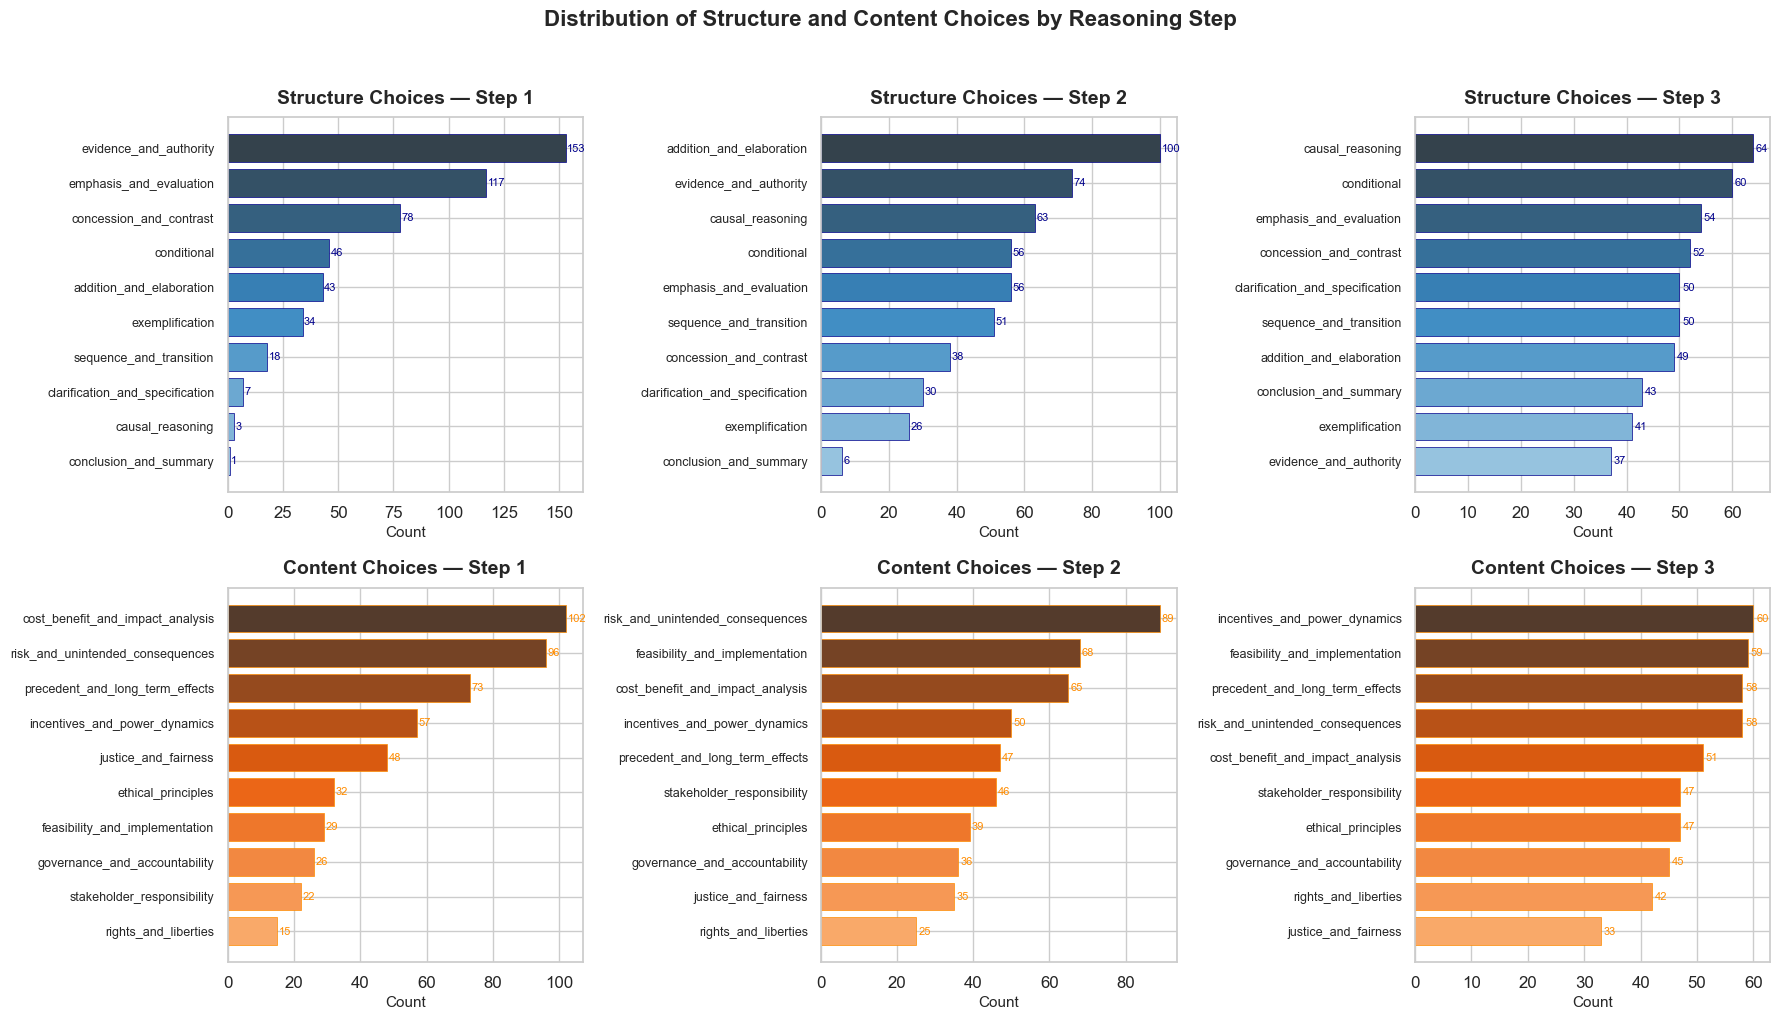

In [295]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style for all plots
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Structure distributions at each step
for i, step in enumerate([1, 2, 3]):
    ax = axes[0, i]
    counts = train_df[f'structure_{step}'].value_counts().sort_values()
    colors = sns.color_palette("Blues_d", n_colors=len(counts))
    ax.barh(y=counts.index, width=counts.values, color=colors, edgecolor='darkblue', linewidth=0.5)
    ax.set_title(f'Structure Choices — Step {step}', fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Count', fontsize=11)
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=9)
    # Add value labels
    for j, v in enumerate(counts.values):
        ax.text(v + 0.5, j, str(v), va='center', fontsize=8, color='darkblue')

# Content distributions at each step
for i, step in enumerate([1, 2, 3]):
    ax = axes[1, i]
    counts = train_df[f'content_{step}'].value_counts().sort_values()
    colors = sns.color_palette("Oranges_d", n_colors=len(counts))
    ax.barh(y=counts.index, width=counts.values, color=colors, edgecolor='darkorange', linewidth=0.5)
    ax.set_title(f'Content Choices — Step {step}', fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Count', fontsize=11)
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=9)
    # Add value labels
    for j, v in enumerate(counts.values):
        ax.text(v + 0.5, j, str(v), va='center', fontsize=8, color='darkorange')

plt.suptitle('Distribution of Structure and Content Choices by Reasoning Step', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('structure_content_distributions.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

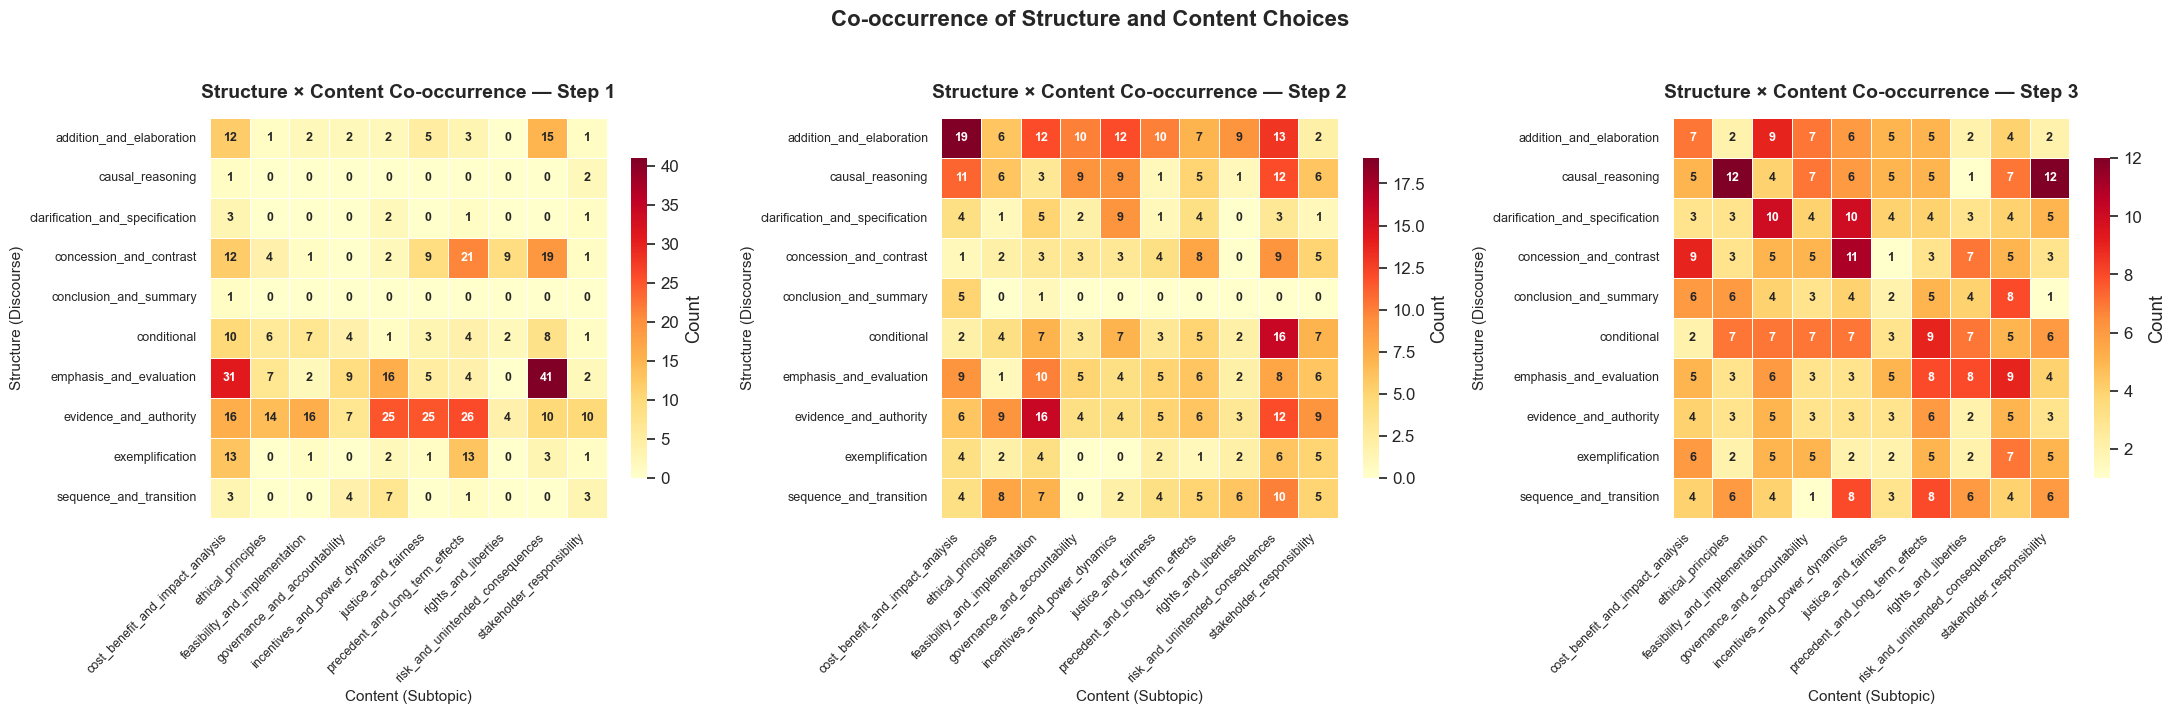

In [296]:
# Structure × Content co-occurrence heatmaps
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for i, step in enumerate([1, 2, 3]):
    ax = axes[i]
    crosstab = pd.crosstab(train_df[f'structure_{step}'], train_df[f'content_{step}'])
    
    # Use a diverging colormap centered at the median
    sns.heatmap(
        crosstab, 
        annot=True, 
        fmt='d', 
        cmap='YlOrRd',
        ax=ax, 
        cbar_kws={'shrink': 0.8, 'label': 'Count'},
        linewidths=0.5,
        linecolor='white',
        annot_kws={'size': 9, 'weight': 'bold'}
    )
    ax.set_title(f'Structure × Content Co-occurrence — Step {step}', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Content (Subtopic)', fontsize=11, fontweight='medium')
    ax.set_ylabel('Structure (Discourse)', fontsize=11, fontweight='medium')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.suptitle('Co-occurrence of Structure and Content Choices', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('structure_content_cooccurrence.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

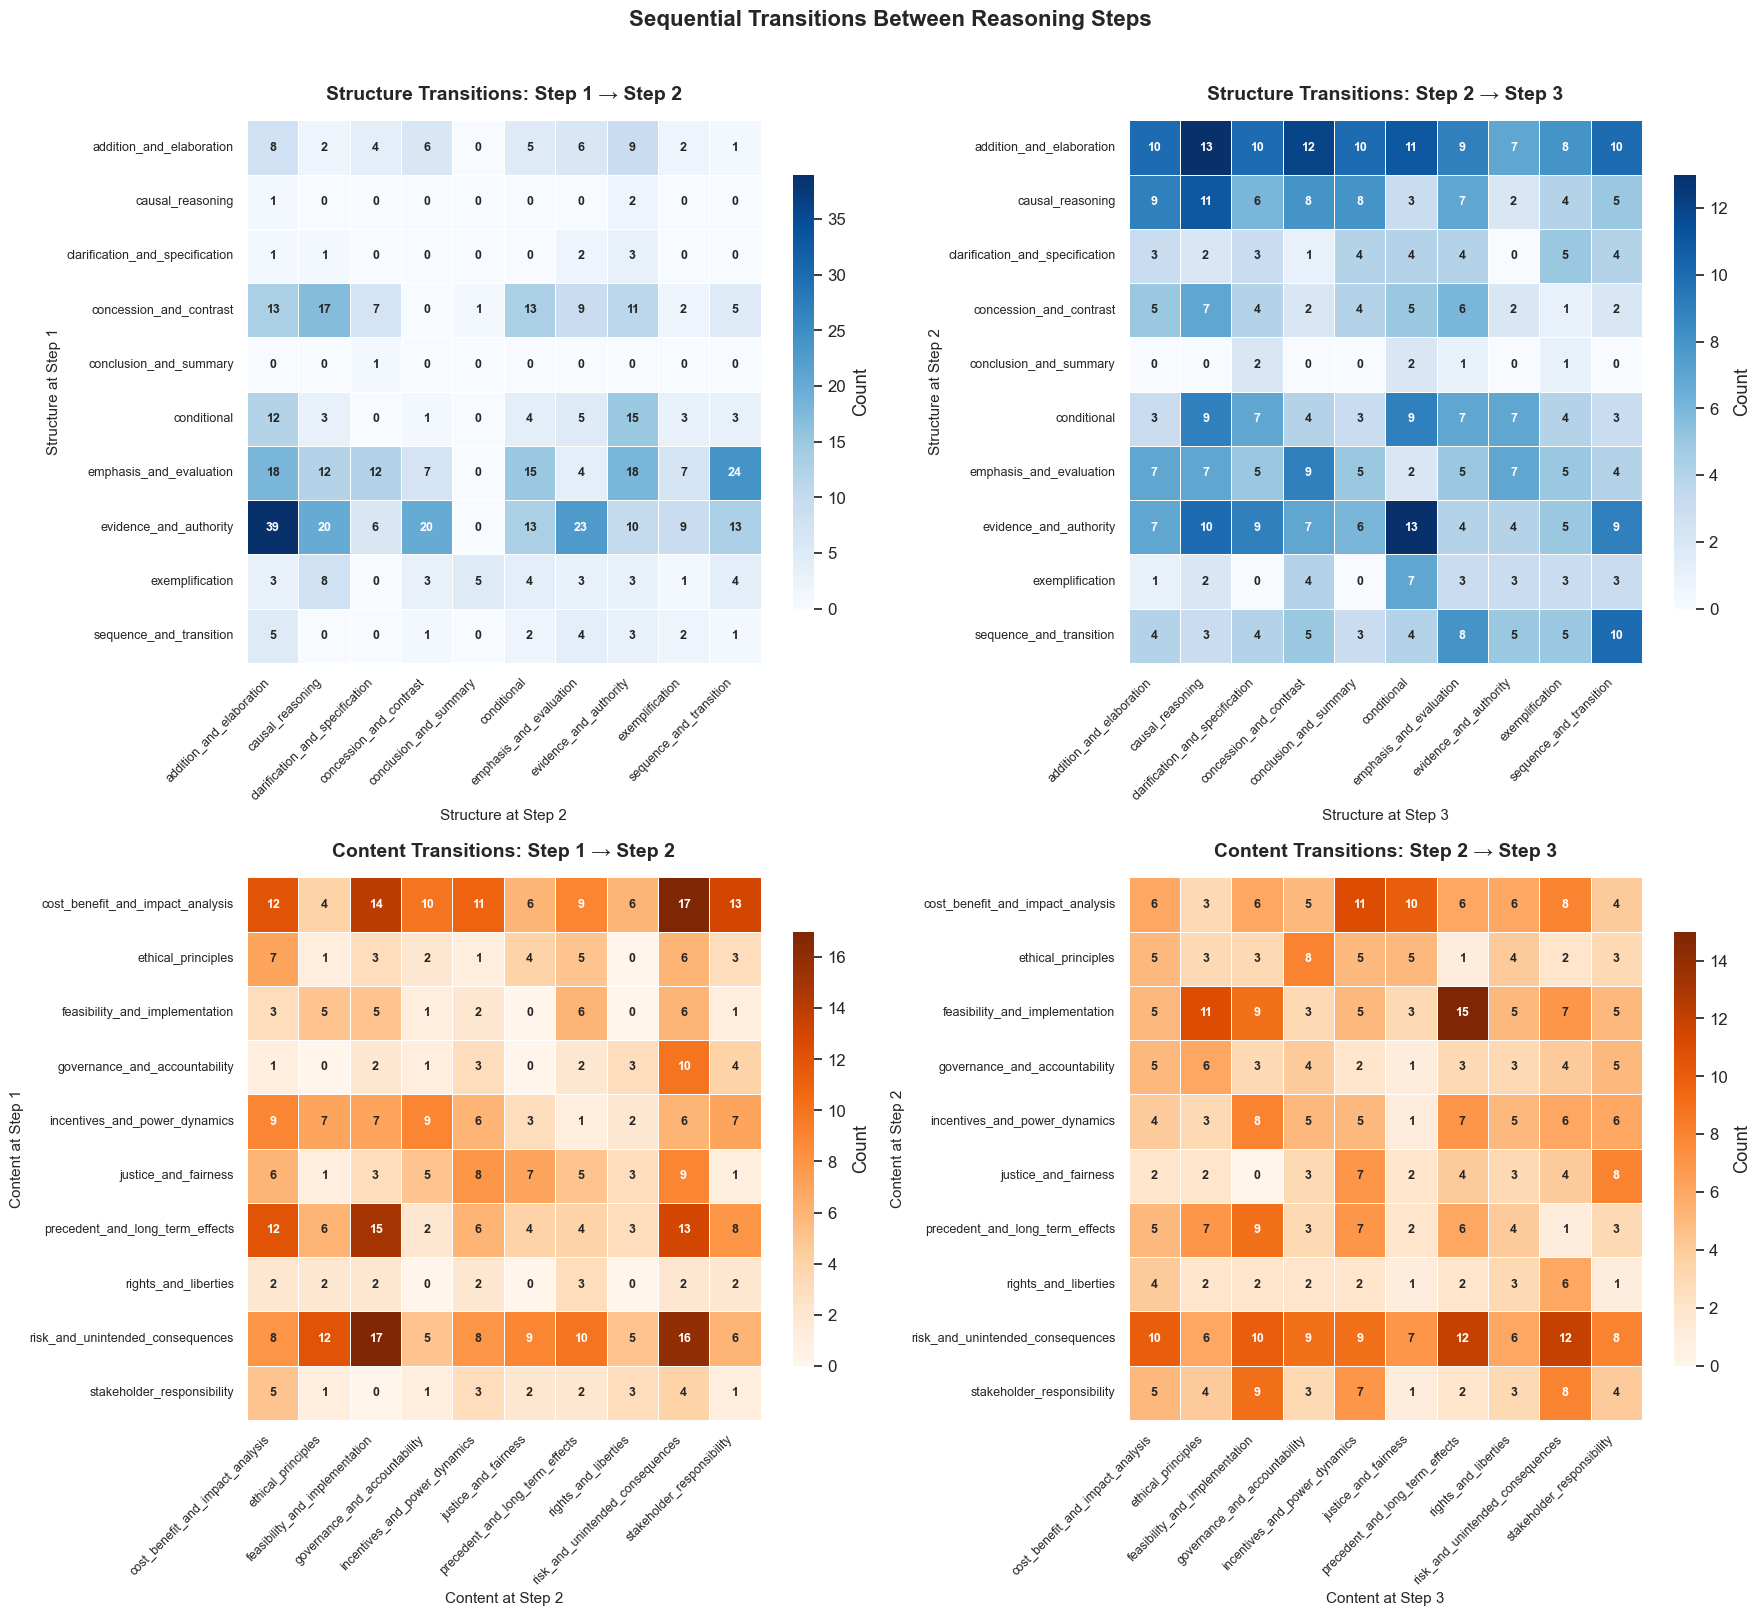

In [297]:
# Structure and Content transition heatmaps (step N → step N+1)
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# Structure transitions
for i, (step1, step2) in enumerate([(1, 2), (2, 3)]):
    ax = axes[0, i]
    crosstab = pd.crosstab(train_df[f'structure_{step1}'], train_df[f'structure_{step2}'])
    sns.heatmap(
        crosstab, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        ax=ax, 
        cbar_kws={'shrink': 0.8, 'label': 'Count'},
        linewidths=0.5,
        linecolor='white',
        annot_kws={'size': 9, 'weight': 'bold'}
    )
    ax.set_title(f'Structure Transitions: Step {step1} → Step {step2}', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel(f'Structure at Step {step2}', fontsize=11, fontweight='medium')
    ax.set_ylabel(f'Structure at Step {step1}', fontsize=11, fontweight='medium')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=9)

# Content transitions
for i, (step1, step2) in enumerate([(1, 2), (2, 3)]):
    ax = axes[1, i]
    crosstab = pd.crosstab(train_df[f'content_{step1}'], train_df[f'content_{step2}'])
    sns.heatmap(
        crosstab, 
        annot=True, 
        fmt='d', 
        cmap='Oranges',
        ax=ax, 
        cbar_kws={'shrink': 0.8, 'label': 'Count'},
        linewidths=0.5,
        linecolor='white',
        annot_kws={'size': 9, 'weight': 'bold'}
    )
    ax.set_title(f'Content Transitions: Step {step1} → Step {step2}', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel(f'Content at Step {step2}', fontsize=11, fontweight='medium')
    ax.set_ylabel(f'Content at Step {step1}', fontsize=11, fontweight='medium')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.suptitle('Sequential Transitions Between Reasoning Steps', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('transitions.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### Regression Models

We progressively build more complex models to understand how structure and content choices affect argument persuasiveness (BT score):

0. **Model 0**: Persona only (baseline - how much variance is explained by persona alone?)
1. **Model 1**: Simple presence dummies (is structure/content used anywhere?) + persona
2. **Model 2**: Position-specific dummies (structure/content at step 1, 2, or 3) + persona
3. **Model 3**: Structure × Content interactions within each step + persona
4. **Model 4**: Chain/sequence features (structure A followed by B) + persona

In [298]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

# Get unique personas for consistent dummy creation
PERSONAS = sorted(train_df['persona_name'].unique().tolist())
print(f"Personas ({len(PERSONAS)}): {PERSONAS}")

def create_persona_only_dummies(df, personas, drop_first=True):
    """Create binary indicators for persona only (baseline model).
    
    Args:
        drop_first: If True, drop first category to avoid multicollinearity (n-1 dummies)
    """
    features = pd.DataFrame(index=df.index)
    
    # Persona dummies - drop first category
    personas_to_use = personas[1:] if drop_first else personas
    for persona in personas_to_use:
        features[f'persona_{persona}'] = (df['persona_name'] == persona).astype(int)
    
    return features


# Create Model 0 features (persona only)
X0_train = create_persona_only_dummies(train_df, PERSONAS, drop_first=True)

# Add constant for intercept
X0_train_const = sm.add_constant(X0_train)

y_train = train_df['bt_score']

# Fit Model 0
model0 = sm.OLS(y_train, X0_train_const).fit()

print("=" * 80)
print("MODEL 0: Persona Only (Baseline)")
print("=" * 80)
print(f"\nReference category (dropped):")
print(f"  Persona: {PERSONAS[0]}")
print(f"\nFeatures: {X0_train.shape[1]} (4 persona dummies)")
print(model0.summary())

Personas (5): ['agreeableness', 'conscientiousness', 'extraversion', 'neuroticism', 'openness']
MODEL 0: Persona Only (Baseline)

Reference category (dropped):
  Persona: agreeableness

Features: 4 (4 persona dummies)
                            OLS Regression Results                            
Dep. Variable:               bt_score   R-squared:                       0.098
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     13.37
Date:                Sun, 11 Jan 2026   Prob (F-statistic):           2.34e-10
Time:                        12:45:21   Log-Likelihood:                -1381.2
No. Observations:                 500   AIC:                             2772.
Df Residuals:                     495   BIC:                             2793.
Df Model:                           4                                         
Covariance Type:            nonrobust                                  

In [299]:
def create_presence_dummies(df, structures, subtopics, personas, drop_first=True):
    """Create binary indicators for presence of each structure/content (anywhere in trajectory).
    
    Args:
        drop_first: If True, drop first category to avoid multicollinearity (n-1 dummies)
    """
    features = pd.DataFrame(index=df.index)
    
    # Structure presence (across all steps) - drop first category
    structs_to_use = structures[1:] if drop_first else structures
    for struct in structs_to_use:
        features[f'has_{struct}'] = (
            (df['structure_1'] == struct) | 
            (df['structure_2'] == struct) | 
            (df['structure_3'] == struct)
        ).astype(int)
    
    # Content presence (across all steps) - drop first category
    subtopics_to_use = subtopics[1:] if drop_first else subtopics
    for subtopic in subtopics_to_use:
        features[f'has_{subtopic}'] = (
            (df['content_1'] == subtopic) | 
            (df['content_2'] == subtopic) | 
            (df['content_3'] == subtopic)
        ).astype(int)
    
    # Persona dummies - drop first category
    personas_to_use = personas[1:] if drop_first else personas
    for persona in personas_to_use:
        features[f'persona_{persona}'] = (df['persona_name'] == persona).astype(int)
    
    return features


# Create Model 1 features (n-1 dummies per category)
X1_train = create_presence_dummies(train_df, STRUCTURES, SUBTOPICS, PERSONAS, drop_first=True)

# Add constant for intercept
X1_train_const = sm.add_constant(X1_train)

# Fit Model 1
model1 = sm.OLS(y_train, X1_train_const).fit()

print("=" * 80)
print("MODEL 1: Simple Presence Dummies + Persona (n-1 per category)")
print("=" * 80)
print(f"\nReference categories (dropped):")
print(f"  Structure: {STRUCTURES[0]}")
print(f"  Content:   {SUBTOPICS[0]}")
print(f"  Persona:   {PERSONAS[0]}")
print(f"\nFeatures: {X1_train.shape[1]} (9 structures + 9 contents + 4 personas)")
print(model1.summary())

MODEL 1: Simple Presence Dummies + Persona (n-1 per category)

Reference categories (dropped):
  Structure: causal_reasoning
  Content:   cost_benefit_and_impact_analysis
  Persona:   agreeableness

Features: 22 (9 structures + 9 contents + 4 personas)
                            OLS Regression Results                            
Dep. Variable:               bt_score   R-squared:                       0.180
Model:                            OLS   Adj. R-squared:                  0.143
Method:                 Least Squares   F-statistic:                     4.772
Date:                Sun, 11 Jan 2026   Prob (F-statistic):           2.29e-11
Time:                        12:45:21   Log-Likelihood:                -1357.1
No. Observations:                 500   AIC:                             2760.
Df Residuals:                     477   BIC:                             2857.
Df Model:                          22                                         
Covariance Type:            nonrobus

In [300]:
def create_position_dummies(df, structures, subtopics, personas, drop_first=True):
    """Create binary indicators for structure/content at each specific position.
    
    Args:
        drop_first: If True, drop first category at each position to avoid multicollinearity
    """
    features = pd.DataFrame(index=df.index)
    
    # Structure at each position - drop first category
    structs_to_use = structures[1:] if drop_first else structures
    for step in [1, 2, 3]:
        for struct in structs_to_use:
            features[f'step{step}_{struct}'] = (df[f'structure_{step}'] == struct).astype(int)
    
    # Content at each position - drop first category
    subtopics_to_use = subtopics[1:] if drop_first else subtopics
    for step in [1, 2, 3]:
        for subtopic in subtopics_to_use:
            features[f'step{step}_{subtopic}'] = (df[f'content_{step}'] == subtopic).astype(int)
    
    # Persona dummies - drop first category
    personas_to_use = personas[1:] if drop_first else personas
    for persona in personas_to_use:
        features[f'persona_{persona}'] = (df['persona_name'] == persona).astype(int)
    
    return features


# Create Model 2 features (n-1 dummies per category at each position)
X2_train = create_position_dummies(train_df, STRUCTURES, SUBTOPICS, PERSONAS, drop_first=True)

# Remove columns with zero variance (never occur in training)
nonzero_cols = X2_train.columns[X2_train.sum() > 0]
X2_train = X2_train[nonzero_cols]

# Add constant
X2_train_const = sm.add_constant(X2_train)

# Fit Model 2
model2 = sm.OLS(y_train, X2_train_const).fit()

print("=" * 80)
print("MODEL 2: Position-Specific Dummies + Persona (n-1 per category)")
print("=" * 80)
print(f"\nReference categories (dropped at each step):")
print(f"  Structure: {STRUCTURES[0]}")
print(f"  Content:   {SUBTOPICS[0]}")
print(f"  Persona:   {PERSONAS[0]}")
print(f"\nFeatures: {X2_train.shape[1]} (after removing zero-variance columns)")
print(f"R²: {model2.rsquared:.4f}, Adj. R²: {model2.rsquared_adj:.4f}")
print(f"AIC: {model2.aic:.2f}, BIC: {model2.bic:.2f}")

# Show significant coefficients
sig_coefs = model2.pvalues[model2.pvalues < 0.05].sort_values()
print(f"\nSignificant coefficients (p < 0.05): {len(sig_coefs)}")
if len(sig_coefs) > 0:
    print("\nTop 10 by significance:")
    for name in sig_coefs.head(10).index:
        print(f"  {name}: coef={model2.params[name]:.4f}, p={model2.pvalues[name]:.4f}")

MODEL 2: Position-Specific Dummies + Persona (n-1 per category)

Reference categories (dropped at each step):
  Structure: causal_reasoning
  Content:   cost_benefit_and_impact_analysis
  Persona:   agreeableness

Features: 58 (after removing zero-variance columns)
R²: 0.2226, Adj. R²: 0.1203
AIC: 2805.78, BIC: 3054.44

Significant coefficients (p < 0.05): 7

Top 10 by significance:
  persona_neuroticism: coef=2.5926, p=0.0000
  step1_ethical_principles: coef=-2.4053, p=0.0048
  step1_precedent_and_long_term_effects: coef=-1.7470, p=0.0061
  step2_emphasis_and_evaluation: coef=1.8854, p=0.0110
  persona_conscientiousness: coef=1.3682, p=0.0205
  step3_emphasis_and_evaluation: coef=1.7069, p=0.0238
  step3_evidence_and_authority: coef=1.8278, p=0.0279


In [301]:
def create_interaction_features(df, structures, subtopics, personas, drop_first=True):
    """Create structure × content interaction features at each step.
    
    Args:
        drop_first: If True, drop first category to avoid multicollinearity
    """
    features = pd.DataFrame(index=df.index)
    
    structs_to_use = structures[1:] if drop_first else structures
    subtopics_to_use = subtopics[1:] if drop_first else subtopics
    
    # Position-specific dummies (from Model 2)
    for step in [1, 2, 3]:
        for struct in structs_to_use:
            features[f'step{step}_{struct}'] = (df[f'structure_{step}'] == struct).astype(int)
        for subtopic in subtopics_to_use:
            features[f'step{step}_{subtopic}'] = (df[f'content_{step}'] == subtopic).astype(int)
    
    # Structure × Content interactions at each step (using all combinations for interactions)
    for step in [1, 2, 3]:
        for struct in structs_to_use:
            for subtopic in subtopics_to_use:
                struct_present = (df[f'structure_{step}'] == struct).astype(int)
                content_present = (df[f'content_{step}'] == subtopic).astype(int)
                features[f'step{step}_{struct}_x_{subtopic}'] = struct_present * content_present
    
    # Persona dummies - drop first category
    personas_to_use = personas[1:] if drop_first else personas
    for persona in personas_to_use:
        features[f'persona_{persona}'] = (df['persona_name'] == persona).astype(int)
    
    return features


# Create Model 3 features
X3_train = create_interaction_features(train_df, STRUCTURES, SUBTOPICS, PERSONAS, drop_first=True)

# Remove zero-variance columns
nonzero_cols = X3_train.columns[X3_train.sum() > 0]
X3_train = X3_train[nonzero_cols]

# Add constant
X3_train_const = sm.add_constant(X3_train)

# Fit Model 3
model3 = sm.OLS(y_train, X3_train_const).fit()

print("=" * 80)
print("MODEL 3: Structure × Content Interactions + Persona (n-1 per category)")
print("=" * 80)
print(f"\nReference categories:")
print(f"  Structure: {STRUCTURES[0]}")
print(f"  Content:   {SUBTOPICS[0]}")
print(f"  Persona:   {PERSONAS[0]}")
print(f"\nFeatures: {X3_train.shape[1]} (position dummies + interactions + persona)")
print(f"R²: {model3.rsquared:.4f}, Adj. R²: {model3.rsquared_adj:.4f}")
print(f"AIC: {model3.aic:.2f}, BIC: {model3.bic:.2f}")

# Show top 10 significant coefficients
sig_coefs = model3.pvalues[model3.pvalues < 0.05].sort_values()
print(f"\nSignificant coefficients (p < 0.05): {len(sig_coefs)}")
if len(sig_coefs) > 0:
    print("\nTop 10 by significance:")
    for name in sig_coefs.head(10).index:
        print(f"  {name}: coef={model3.params[name]:.4f}, p={model3.pvalues[name]:.4f}")

MODEL 3: Structure × Content Interactions + Persona (n-1 per category)

Reference categories:
  Structure: causal_reasoning
  Content:   cost_benefit_and_impact_analysis
  Persona:   agreeableness

Features: 262 (position dummies + interactions + persona)
R²: 0.5058, Adj. R²: -0.0025
AIC: 2969.27, BIC: 4039.78

Significant coefficients (p < 0.05): 18

Top 10 by significance:
  persona_neuroticism: coef=4.0600, p=0.0001
  step3_evidence_and_authority: coef=12.7634, p=0.0002
  step3_evidence_and_authority_x_governance_and_accountability: coef=-16.7912, p=0.0007
  step3_evidence_and_authority_x_risk_and_unintended_consequences: coef=-14.1955, p=0.0035
  persona_conscientiousness: coef=2.6053, p=0.0077
  step1_evidence_and_authority_x_precedent_and_long_term_effects: coef=-5.5574, p=0.0102
  step3_evidence_and_authority_x_stakeholder_responsibility: coef=-11.7816, p=0.0129
  step2_emphasis_and_evaluation_x_precedent_and_long_term_effects: coef=10.0018, p=0.0145
  step2_sequence_and_transit

/var/folders/1n/l1qs9bwj2h9c06x52w17rfdm0000gp/T/ipykernel_11311/2154010024.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features[f'step{step}_{struct}_x_{subtopic}'] = struct_present * content_present
/var/folders/1n/l1qs9bwj2h9c06x52w17rfdm0000gp/T/ipykernel_11311/2154010024.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features[f'step{step}_{struct}_x_{subtopic}'] = struct_present * content_present
/var/folders/1n/l1qs9bwj2h9c06x52w17rfdm0000gp/T/ipykernel_11311/2154010024.py:25: PerformanceWarning: DataFrame i

In [302]:
def create_chain_features(df, structures, subtopics, personas, drop_first=True):
    """Create sequential chain features (step N → step N+1 transitions).
    
    Args:
        drop_first: If True, drop first category to avoid multicollinearity
    """
    features = pd.DataFrame(index=df.index)
    
    structs_to_use = structures[1:] if drop_first else structures
    subtopics_to_use = subtopics[1:] if drop_first else subtopics
    
    # Position-specific dummies (base features)
    for step in [1, 2, 3]:
        for struct in structs_to_use:
            features[f'step{step}_{struct}'] = (df[f'structure_{step}'] == struct).astype(int)
        for subtopic in subtopics_to_use:
            features[f'step{step}_{subtopic}'] = (df[f'content_{step}'] == subtopic).astype(int)
    
    # Structure chains: step1→step2 and step2→step3
    for step1, step2 in [(1, 2), (2, 3)]:
        for struct1 in structs_to_use:
            for struct2 in structs_to_use:
                s1_present = (df[f'structure_{step1}'] == struct1).astype(int)
                s2_present = (df[f'structure_{step2}'] == struct2).astype(int)
                features[f'struct_{struct1}_then_{struct2}_s{step1}s{step2}'] = s1_present * s2_present
    
    # Content chains: step1→step2 and step2→step3
    for step1, step2 in [(1, 2), (2, 3)]:
        for sub1 in subtopics_to_use:
            for sub2 in subtopics_to_use:
                c1_present = (df[f'content_{step1}'] == sub1).astype(int)
                c2_present = (df[f'content_{step2}'] == sub2).astype(int)
                features[f'content_{sub1}_then_{sub2}_s{step1}s{step2}'] = c1_present * c2_present
    
    # Persona dummies - drop first category
    personas_to_use = personas[1:] if drop_first else personas
    for persona in personas_to_use:
        features[f'persona_{persona}'] = (df['persona_name'] == persona).astype(int)
    
    return features


# Create Model 4 features
X4_train = create_chain_features(train_df, STRUCTURES, SUBTOPICS, PERSONAS, drop_first=True)

# Remove zero-variance columns
nonzero_cols = X4_train.columns[X4_train.sum() > 0]
X4_train = X4_train[nonzero_cols]

# Add constant
X4_train_const = sm.add_constant(X4_train)

# Fit Model 4
model4 = sm.OLS(y_train, X4_train_const).fit()

print("=" * 80)
print("MODEL 4: Chain/Sequence Features + Persona (n-1 per category)")
print("=" * 80)
print(f"\nReference categories:")
print(f"  Structure: {STRUCTURES[0]}")
print(f"  Content:   {SUBTOPICS[0]}")
print(f"  Persona:   {PERSONAS[0]}")
print(f"\nFeatures: {X4_train.shape[1]} (position dummies + chain transitions + persona)")
print(f"R²: {model4.rsquared:.4f}, Adj. R²: {model4.rsquared_adj:.4f}")
print(f"AIC: {model4.aic:.2f}, BIC: {model4.bic:.2f}")

# Show top 10 significant coefficients
sig_coefs = model4.pvalues[model4.pvalues < 0.05].sort_values()
print(f"\nSignificant coefficients (p < 0.05): {len(sig_coefs)}")
if len(sig_coefs) > 0:
    print("\nTop 10 by significance:")
    for name in sig_coefs.head(10).index:
        print(f"  {name}: coef={model4.params[name]:.4f}, p={model4.pvalues[name]:.4f}")

MODEL 4: Chain/Sequence Features + Persona (n-1 per category)

Reference categories:
  Structure: causal_reasoning
  Content:   cost_benefit_and_impact_analysis
  Persona:   agreeableness

Features: 341 (position dummies + chain transitions + persona)
R²: 0.6007, Adj. R²: -0.1585
AIC: 3010.67, BIC: 4393.06

Significant coefficients (p < 0.05): 13

Top 10 by significance:
  content_precedent_and_long_term_effects_then_feasibility_and_implementation_s2s3: coef=-17.9724, p=0.0009
  content_precedent_and_long_term_effects_then_rights_and_liberties_s2s3: coef=-18.5368, p=0.0012
  content_precedent_and_long_term_effects_then_precedent_and_long_term_effects_s2s3: coef=-17.5377, p=0.0014
  content_precedent_and_long_term_effects_then_incentives_and_power_dynamics_s2s3: coef=-17.2442, p=0.0021
  content_precedent_and_long_term_effects_then_justice_and_fairness_s2s3: coef=-19.6268, p=0.0035
  content_precedent_and_long_term_effects_then_governance_and_accountability_s2s3: coef=-18.3205, p=0.0045

/var/folders/1n/l1qs9bwj2h9c06x52w17rfdm0000gp/T/ipykernel_11311/2177982767.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features[f'struct_{struct1}_then_{struct2}_s{step1}s{step2}'] = s1_present * s2_present
/var/folders/1n/l1qs9bwj2h9c06x52w17rfdm0000gp/T/ipykernel_11311/2177982767.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features[f'struct_{struct1}_then_{struct2}_s{step1}s{step2}'] = s1_present * s2_present
/var/folders/1n/l1qs9bwj2h9c06x52w17rfdm0000gp/T/ipykernel_11311/2177982767.py:25: PerformanceWarnin

### Model Comparison and Evaluation

In [303]:
# Model comparison on TRAINING data only (test set held out for final evaluation)

def summarize_model(model, X_train, name):
    """Summarize model performance on training data."""
    return {
        'Model': name,
        'R²': model.rsquared,
        'Adj. R²': model.rsquared_adj,
        'AIC': model.aic,
        'BIC': model.bic,
        'N Features': X_train.shape[1],
        'Sig. Coefs (p<0.05)': (model.pvalues < 0.05).sum(),
        'F-statistic': model.fvalue,
        'Prob(F)': model.f_pvalue,
    }

# Summarize all models (including Model 0 baseline)
results = [
    summarize_model(model0, X0_train, 'Model 0: Persona Only'),
    summarize_model(model1, X1_train, 'Model 1: Presence'),
    summarize_model(model2, X2_train, 'Model 2: Position'),
    summarize_model(model3, X3_train, 'Model 3: Interactions'),
    summarize_model(model4, X4_train, 'Model 4: Chains'),
]

comparison_df = pd.DataFrame(results)

print("=" * 100)
print("MODEL COMPARISON (Training Data Only — Test Set Held Out)")
print("=" * 100)
print(f"\nTraining samples: {len(train_df)}")
print(f"Holdout test samples: {len(test_df)} (reserved for final model evaluation)")
print(f"\nReference categories (dropped for n-1 encoding):")
print(f"  Structure: {STRUCTURES[0]}")
print(f"  Content:   {SUBTOPICS[0]}")
print(f"  Persona:   {PERSONAS[0]}")
print()
print(comparison_df.to_string(index=False))

MODEL COMPARISON (Training Data Only — Test Set Held Out)

Training samples: 500
Holdout test samples: 250 (reserved for final model evaluation)

Reference categories (dropped for n-1 encoding):
  Structure: causal_reasoning
  Content:   cost_benefit_and_impact_analysis
  Persona:   agreeableness

                Model       R²   Adj. R²         AIC         BIC  N Features  Sig. Coefs (p<0.05)  F-statistic      Prob(F)
Model 0: Persona Only 0.097538  0.090246 2772.345425 2793.418466           4                    2    13.374936 2.338830e-10
    Model 1: Presence 0.180403  0.142602 2760.188760 2857.124746          22                    5     4.772421 2.285575e-11
    Model 2: Position 0.222565  0.120318 2805.782123 3054.444001          58                    7     2.176728 5.782328e-06
Model 3: Interactions 0.505779 -0.002504 2969.273260 4039.783717         262                   18     0.995073 5.157775e-01
      Model 4: Chains 0.600673 -0.158511 3010.672046 4393.063503         341     

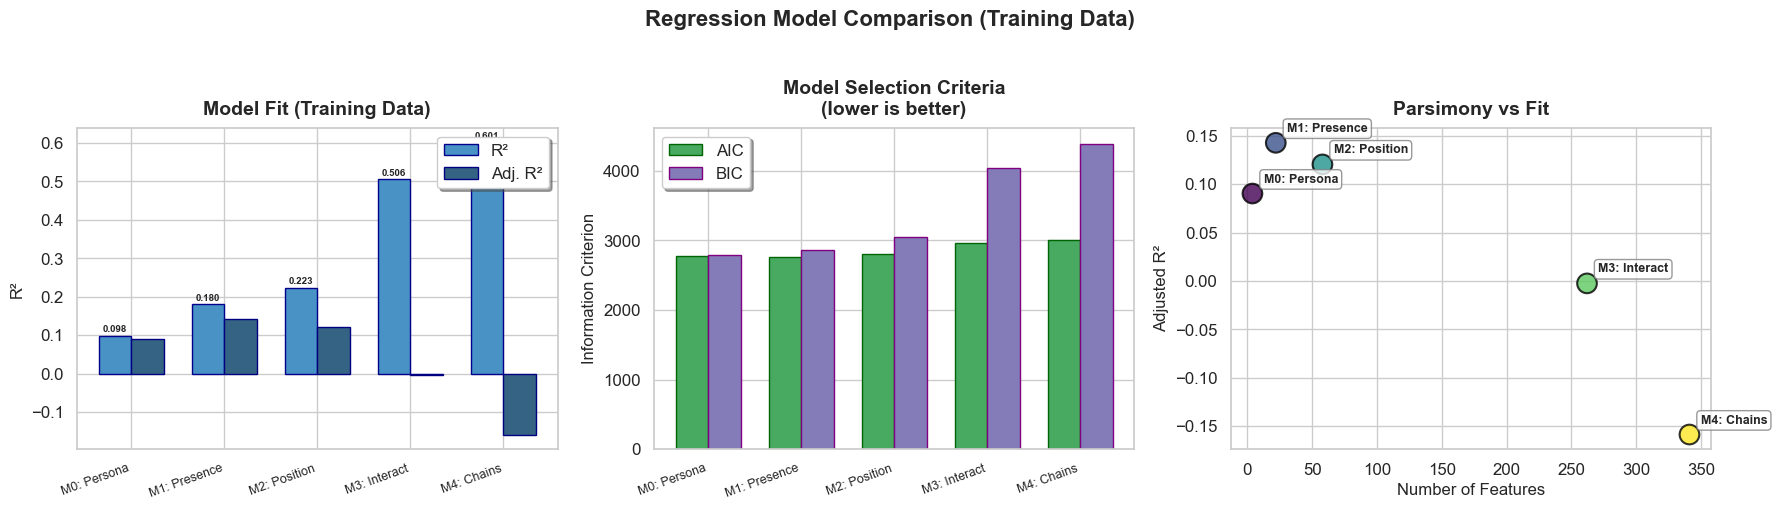

In [304]:
# Visualize model comparison (training data only)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = ['M0: Persona', 'M1: Presence', 'M2: Position', 'M3: Interact', 'M4: Chains']
x = np.arange(len(models))

# Color palette
r2_color = sns.color_palette("Blues_d")[2]
adj_r2_color = sns.color_palette("Blues_d")[4]
aic_color = sns.color_palette("Greens_d")[2]
bic_color = sns.color_palette("Purples_d")[2]

# R² and Adjusted R² comparison
ax = axes[0]
width = 0.35
bars1 = ax.bar(x - width/2, comparison_df['R²'], width, label='R²', color=r2_color, edgecolor='darkblue', linewidth=1)
bars2 = ax.bar(x + width/2, comparison_df['Adj. R²'], width, label='Adj. R²', color=adj_r2_color, edgecolor='navy', linewidth=1)
ax.set_ylabel('R²', fontsize=12, fontweight='medium')
ax.set_title('Model Fit (Training Data)', fontsize=14, fontweight='bold', pad=10)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha='right', fontsize=9)
ax.legend(frameon=True, fancybox=True, shadow=True, loc='upper right')
# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{bar.get_height():.3f}', 
            ha='center', va='bottom', fontsize=7, fontweight='bold')

# AIC/BIC comparison (lower is better)
ax = axes[1]
bars1 = ax.bar(x - width/2, comparison_df['AIC'], width, label='AIC', color=aic_color, edgecolor='darkgreen', linewidth=1)
bars2 = ax.bar(x + width/2, comparison_df['BIC'], width, label='BIC', color=bic_color, edgecolor='purple', linewidth=1)
ax.set_ylabel('Information Criterion', fontsize=12, fontweight='medium')
ax.set_title('Model Selection Criteria\n(lower is better)', fontsize=14, fontweight='bold', pad=10)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha='right', fontsize=9)
ax.legend(frameon=True, fancybox=True, shadow=True, loc='upper left')

# Feature count vs Adjusted R² (parsimony vs fit)
ax = axes[2]
scatter = ax.scatter(
    comparison_df['N Features'], 
    comparison_df['Adj. R²'], 
    s=200, 
    c=range(len(models)), 
    cmap='viridis',
    edgecolors='black',
    linewidth=1.5,
    alpha=0.8
)
for i, model in enumerate(models):
    ax.annotate(
        model, 
        (comparison_df['N Features'].iloc[i], comparison_df['Adj. R²'].iloc[i]), 
        textcoords="offset points", 
        xytext=(8, 8), 
        fontsize=9,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8)
    )
ax.set_xlabel('Number of Features', fontsize=12, fontweight='medium')
ax.set_ylabel('Adjusted R²', fontsize=12, fontweight='medium')
ax.set_title('Parsimony vs Fit', fontsize=14, fontweight='bold', pad=10)

plt.suptitle('Regression Model Comparison (Training Data)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [305]:
# Analyze best model's significant predictors
# Choose best model based on test R² and parsimony
best_model = model3  # Position-specific dummies (good balance of interpretability and performance)
best_name = "Model 3 (Interactions)"

print("=" * 80)
print(f"DETAILED ANALYSIS: {best_name}")
print("=" * 80)

# Get significant coefficients sorted by absolute effect size
sig_mask = best_model.pvalues < 0.05
sig_coefs = pd.DataFrame({
    'Coefficient': best_model.params[sig_mask],
    'Std Error': best_model.bse[sig_mask],
    'p-value': best_model.pvalues[sig_mask],
    'CI Lower': best_model.conf_int()[sig_mask][0],
    'CI Upper': best_model.conf_int()[sig_mask][1],
})
sig_coefs = sig_coefs.sort_values('Coefficient', key=abs, ascending=False)

print(f"\nSignificant predictors (p < 0.05): {len(sig_coefs)}")
print("\nTop 15 by absolute effect size:")
print(sig_coefs.head(15).to_string())

# Separate positive and negative effects
positive_effects = sig_coefs[sig_coefs['Coefficient'] > 0].head(10)
negative_effects = sig_coefs[sig_coefs['Coefficient'] < 0].head(10)

print("\n" + "=" * 80)
print("TOP 10 POSITIVE EFFECTS (increase BT score)")
print("=" * 80)
for name, row in positive_effects.iterrows():
    print(f"  {name}: +{row['Coefficient']:.4f} (p={row['p-value']:.4f})")

print("\n" + "=" * 80)
print("TOP 10 NEGATIVE EFFECTS (decrease BT score)")
print("=" * 80)
for name, row in negative_effects.iterrows():
    print(f"  {name}: {row['Coefficient']:.4f} (p={row['p-value']:.4f})")

DETAILED ANALYSIS: Model 3 (Interactions)

Significant predictors (p < 0.05): 18

Top 15 by absolute effect size:
                                                                  Coefficient  Std Error   p-value   CI Lower   CI Upper
step3_evidence_and_authority_x_governance_and_accountability       -16.791226   4.868052  0.000661 -26.379605  -7.202847
step3_evidence_and_authority_x_risk_and_unintended_consequences    -14.195543   4.814291  0.003499 -23.678031  -4.713054
step3_evidence_and_authority                                        12.763444   3.379628  0.000199   6.106746  19.420141
step3_evidence_and_authority_x_justice_and_fairness                -11.806146   5.072917  0.020762 -21.798039  -1.814253
step3_evidence_and_authority_x_stakeholder_responsibility          -11.781565   4.704369  0.012914 -21.047544  -2.515585
step3_evidence_and_authority_x_incentives_and_power_dynamics       -11.265254   5.083685  0.027610 -21.278355  -1.252154
step3_evidence_and_authority_x_feasibil

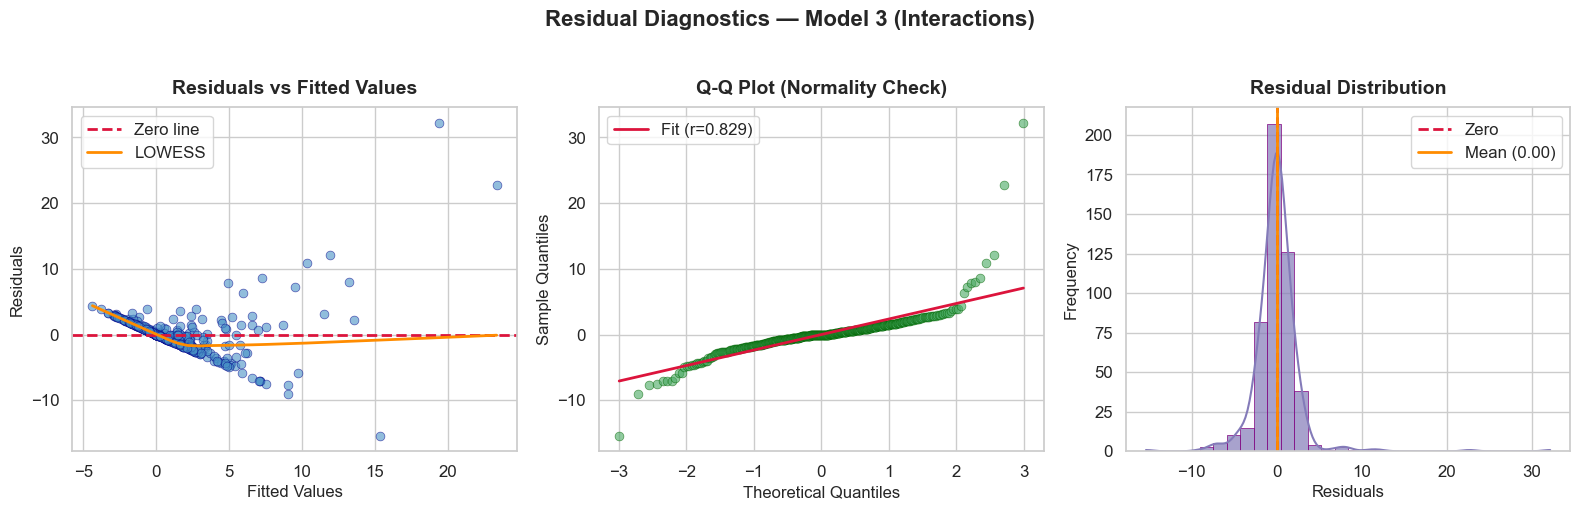


Breusch-Pagan Test for Heteroskedasticity
  LM statistic: 240.6776
  p-value:      0.8235
  Result:       ✓ Homoskedasticity assumption holds


In [306]:
# Residual diagnostics for best model with seaborn styling
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

fitted = best_model.fittedvalues
residuals = best_model.resid

# Fitted vs Residuals
ax = axes[0]
sns.scatterplot(x=fitted, y=residuals, ax=ax, alpha=0.6, s=40, color=sns.color_palette("Blues_d")[2], edgecolor='darkblue', linewidth=0.5)
ax.axhline(y=0, color='crimson', linestyle='--', linewidth=2, label='Zero line')
# Add lowess smoothing line
from statsmodels.nonparametric.smoothers_lowess import lowess
smoothed = lowess(residuals, fitted, frac=0.3)
ax.plot(smoothed[:, 0], smoothed[:, 1], color='darkorange', linewidth=2, label='LOWESS')
ax.set_xlabel('Fitted Values', fontsize=12, fontweight='medium')
ax.set_ylabel('Residuals', fontsize=12, fontweight='medium')
ax.set_title('Residuals vs Fitted Values', fontsize=14, fontweight='bold', pad=10)
ax.legend(frameon=True, fancybox=True)

# Q-Q plot
ax = axes[1]
from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist="norm")
ax.scatter(osm, osr, alpha=0.6, s=40, color=sns.color_palette("Greens_d")[2], edgecolor='darkgreen', linewidth=0.5)
ax.plot(osm, slope * osm + intercept, color='crimson', linewidth=2, label=f'Fit (r={r:.3f})')
ax.set_xlabel('Theoretical Quantiles', fontsize=12, fontweight='medium')
ax.set_ylabel('Sample Quantiles', fontsize=12, fontweight='medium')
ax.set_title('Q-Q Plot (Normality Check)', fontsize=14, fontweight='bold', pad=10)
ax.legend(frameon=True, fancybox=True)

# Histogram of residuals with KDE
ax = axes[2]
sns.histplot(residuals, bins=30, kde=True, ax=ax, color=sns.color_palette("Purples_d")[2], edgecolor='purple', linewidth=0.5, alpha=0.7)
ax.axvline(x=0, color='crimson', linestyle='--', linewidth=2, label='Zero')
ax.axvline(x=residuals.mean(), color='darkorange', linestyle='-', linewidth=2, label=f'Mean ({residuals.mean():.2f})')
ax.set_xlabel('Residuals', fontsize=12, fontweight='medium')
ax.set_ylabel('Frequency', fontsize=12, fontweight='medium')
ax.set_title('Residual Distribution', fontsize=14, fontweight='bold', pad=10)
ax.legend(frameon=True, fancybox=True)

plt.suptitle(f'Residual Diagnostics — {best_name}', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('residual_diagnostics.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Test for heteroskedasticity
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(residuals, best_model.model.exog)
print(f"\n{'='*60}")
print("Breusch-Pagan Test for Heteroskedasticity")
print(f"{'='*60}")
print(f"  LM statistic: {bp_test[0]:.4f}")
print(f"  p-value:      {bp_test[1]:.4f}")
print(f"  Result:       {'⚠️ Heteroskedasticity detected' if bp_test[1] < 0.05 else '✓ Homoskedasticity assumption holds'}")

### Holdout Test Set Evaluation

Evaluate Model 0 (persona only baseline), Model 1 (presence dummies + persona), and Model 3 (structure × content interactions + persona) on the 250-sample holdout test set.

In [307]:
# Test Set Evaluation: Model 0, Model 1, and Model 3
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Create test features for Model 0 (persona only)
X0_test = create_persona_only_dummies(test_df, PERSONAS, drop_first=True)
X0_test_const = sm.add_constant(X0_test)

# Create test features for Model 1 (presence dummies + persona)
X1_test = create_presence_dummies(test_df, STRUCTURES, SUBTOPICS, PERSONAS, drop_first=True)
X1_test_const = sm.add_constant(X1_test)

# Create test features for Model 3 (interaction features + persona)
X3_test = create_interaction_features(test_df, STRUCTURES, SUBTOPICS, PERSONAS, drop_first=True)
# Keep only columns that exist in training (handle unseen feature combos)
X3_test = X3_test.reindex(columns=X3_train.columns, fill_value=0)
X3_test_const = sm.add_constant(X3_test)

y_test = test_df['bt_score']

# Make predictions
y_pred_m0 = model0.predict(X0_test_const)
y_pred_m1 = model1.predict(X1_test_const)
y_pred_m3 = model3.predict(X3_test_const)

# Calculate metrics
def calc_metrics(y_true, y_pred, name):
    """Calculate regression metrics."""
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    # Mean Absolute Percentage Error (handle zeros)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    
    return {
        'Model': name,
        'R²': r2,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape,
        'Max Error': np.max(np.abs(y_true - y_pred)),
    }

# Get metrics for all models
test_results = [
    calc_metrics(y_test, y_pred_m0, 'Model 0: Persona Only'),
    calc_metrics(y_test, y_pred_m1, 'Model 1: Presence + Persona'),
    calc_metrics(y_test, y_pred_m3, 'Model 3: Interactions + Persona'),
]

test_results_df = pd.DataFrame(test_results)

print("=" * 80)
print("HOLDOUT TEST SET EVALUATION (250 samples)")
print("=" * 80)
print(f"\nTest set BT score range: [{y_test.min():.3f}, {y_test.max():.3f}]")
print(f"Test set BT score mean:  {y_test.mean():.3f}")
print(f"Test set BT score std:   {y_test.std():.3f}")
print()
print(test_results_df.to_string(index=False))

# Compare training vs test performance
print("\n" + "=" * 80)
print("TRAINING vs TEST COMPARISON")
print("=" * 80)

comparison_data = [
    {
        'Model': 'Model 0: Persona Only',
        'Train R²': model0.rsquared,
        'Train Adj. R²': model0.rsquared_adj,
        'Test R²': r2_score(y_test, y_pred_m0),
        'Overfit Gap': model0.rsquared - r2_score(y_test, y_pred_m0),
    },
    {
        'Model': 'Model 1: Presence + Persona',
        'Train R²': model1.rsquared,
        'Train Adj. R²': model1.rsquared_adj,
        'Test R²': r2_score(y_test, y_pred_m1),
        'Overfit Gap': model1.rsquared - r2_score(y_test, y_pred_m1),
    },
    {
        'Model': 'Model 3: Interactions + Persona',
        'Train R²': model3.rsquared,
        'Train Adj. R²': model3.rsquared_adj,
        'Test R²': r2_score(y_test, y_pred_m3),
        'Overfit Gap': model3.rsquared - r2_score(y_test, y_pred_m3),
    },
]

comparison_train_test = pd.DataFrame(comparison_data)
print()
print(comparison_train_test.to_string(index=False))

print("\n⚠️ Note: Negative Test R² indicates the model performs worse than a constant mean predictor on unseen data.")

HOLDOUT TEST SET EVALUATION (250 samples)

Test set BT score range: [0.000, 25.311]
Test set BT score mean:  0.940
Test set BT score std:   2.778

                          Model        R²     RMSE      MAE      MAPE (%)  Max Error
          Model 0: Persona Only  0.111109 2.613986 1.052807   5270.919861  23.424758
    Model 1: Presence + Persona  0.097735 2.633577 1.508388  68123.199239  23.476105
Model 3: Interactions + Persona -0.763215 3.681558 2.798865 159219.418577  11.612645

TRAINING vs TEST COMPARISON

                          Model  Train R²  Train Adj. R²   Test R²  Overfit Gap
          Model 0: Persona Only  0.097538       0.090246  0.111109    -0.013571
    Model 1: Presence + Persona  0.180403       0.142602  0.097735     0.082668
Model 3: Interactions + Persona  0.505779      -0.002504 -0.763215     1.268994

⚠️ Note: Negative Test R² indicates the model performs worse than a constant mean predictor on unseen data.


/var/folders/1n/l1qs9bwj2h9c06x52w17rfdm0000gp/T/ipykernel_11311/2154010024.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features[f'step{step}_{struct}_x_{subtopic}'] = struct_present * content_present
/var/folders/1n/l1qs9bwj2h9c06x52w17rfdm0000gp/T/ipykernel_11311/2154010024.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features[f'step{step}_{struct}_x_{subtopic}'] = struct_present * content_present
/var/folders/1n/l1qs9bwj2h9c06x52w17rfdm0000gp/T/ipykernel_11311/2154010024.py:25: PerformanceWarning: DataFrame i

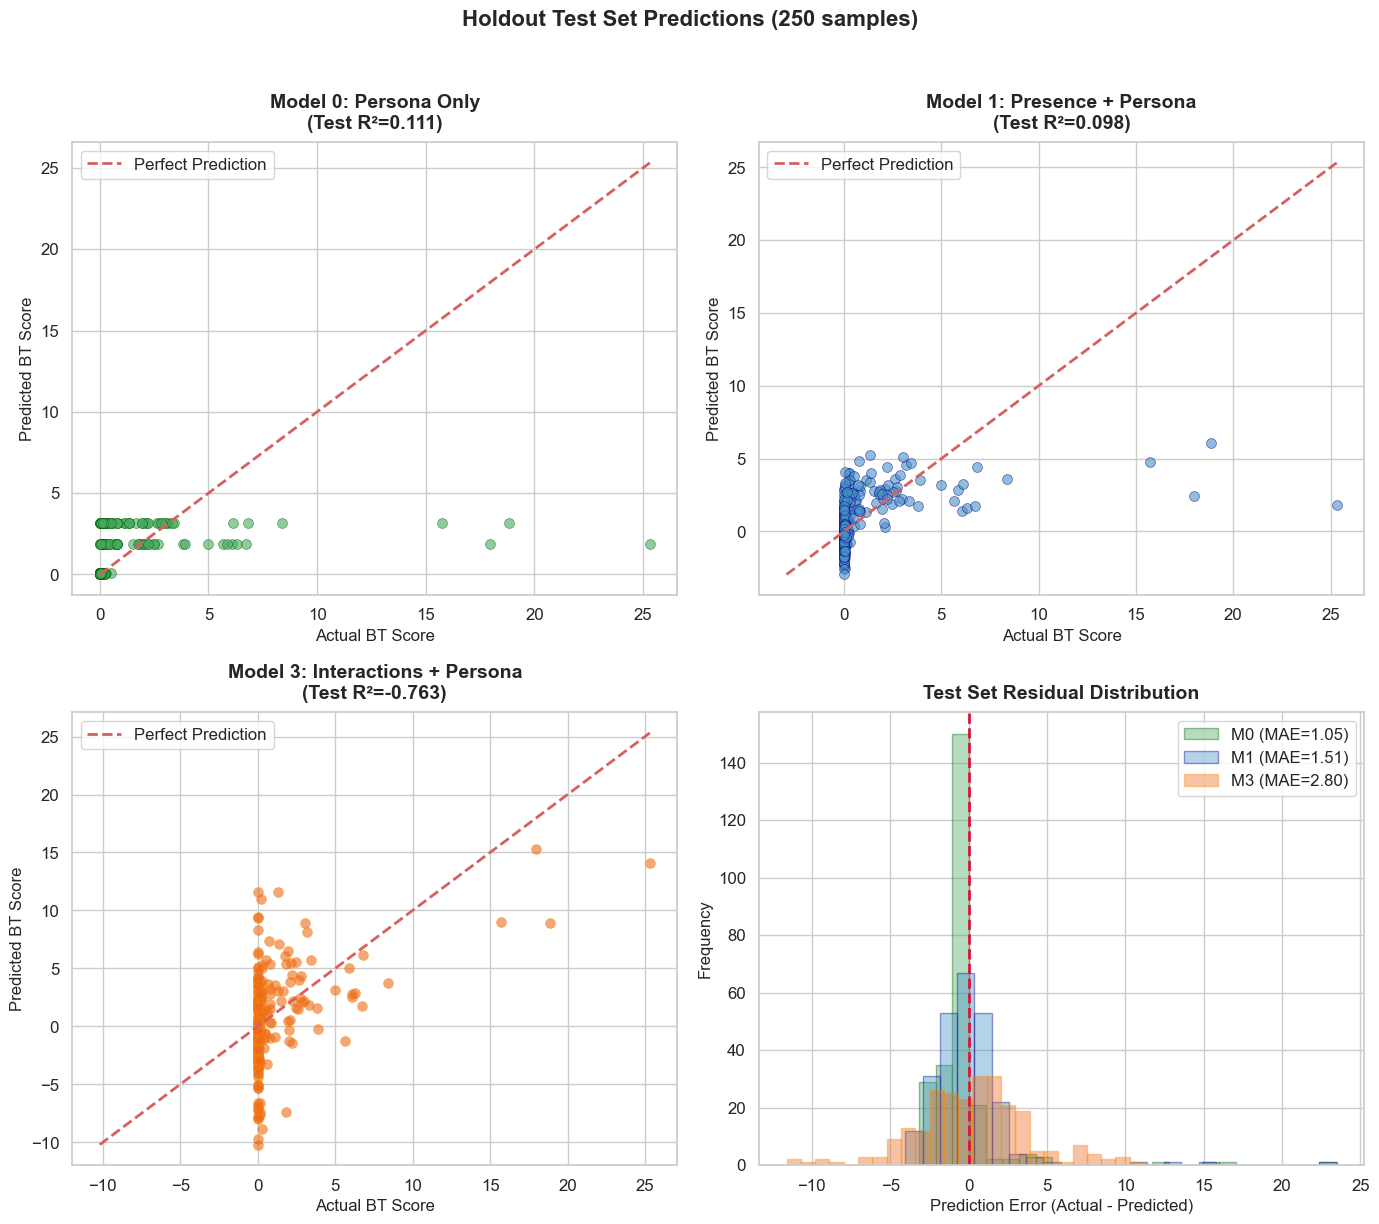

In [308]:
# Visualize test set predictions
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Predicted vs Actual for Model 0
ax = axes[0, 0]
ax.scatter(y_test, y_pred_m0, alpha=0.6, s=50, color=sns.color_palette("Greens_d")[2], edgecolor='darkgreen', linewidth=0.5)
lims = [min(y_test.min(), y_pred_m0.min()), max(y_test.max(), y_pred_m0.max())]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual BT Score', fontsize=12, fontweight='medium')
ax.set_ylabel('Predicted BT Score', fontsize=12, fontweight='medium')
ax.set_title(f'Model 0: Persona Only\n(Test R²={r2_score(y_test, y_pred_m0):.3f})', fontsize=14, fontweight='bold', pad=10)
ax.legend(frameon=True, fancybox=True)

# Predicted vs Actual for Model 1
ax = axes[0, 1]
ax.scatter(y_test, y_pred_m1, alpha=0.6, s=50, color=sns.color_palette("Blues_d")[2], edgecolor='darkblue', linewidth=0.5)
lims = [min(y_test.min(), y_pred_m1.min()), max(y_test.max(), y_pred_m1.max())]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual BT Score', fontsize=12, fontweight='medium')
ax.set_ylabel('Predicted BT Score', fontsize=12, fontweight='medium')
ax.set_title(f'Model 1: Presence + Persona\n(Test R²={r2_score(y_test, y_pred_m1):.3f})', fontsize=14, fontweight='bold', pad=10)
ax.legend(frameon=True, fancybox=True)

# Predicted vs Actual for Model 3
ax = axes[1, 0]
ax.scatter(y_test, y_pred_m3, alpha=0.6, s=50, color=sns.color_palette("Oranges_d")[2], edgecolor='darkorange', linewidth=0.5)
lims = [min(y_test.min(), y_pred_m3.min()), max(y_test.max(), y_pred_m3.max())]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual BT Score', fontsize=12, fontweight='medium')
ax.set_ylabel('Predicted BT Score', fontsize=12, fontweight='medium')
ax.set_title(f'Model 3: Interactions + Persona\n(Test R²={r2_score(y_test, y_pred_m3):.3f})', fontsize=14, fontweight='bold', pad=10)
ax.legend(frameon=True, fancybox=True)

# Residual comparison
ax = axes[1, 1]
residuals_m0 = y_test - y_pred_m0
residuals_m1 = y_test - y_pred_m1
residuals_m3 = y_test - y_pred_m3
ax.hist(residuals_m0, bins=25, alpha=0.4, label=f'M0 (MAE={mean_absolute_error(y_test, y_pred_m0):.2f})', 
        color=sns.color_palette("Greens_d")[2], edgecolor='darkgreen')
ax.hist(residuals_m1, bins=25, alpha=0.4, label=f'M1 (MAE={mean_absolute_error(y_test, y_pred_m1):.2f})', 
        color=sns.color_palette("Blues_d")[2], edgecolor='darkblue')
ax.hist(residuals_m3, bins=25, alpha=0.4, label=f'M3 (MAE={mean_absolute_error(y_test, y_pred_m3):.2f})', 
        color=sns.color_palette("Oranges_d")[2], edgecolor='darkorange')
ax.axvline(x=0, color='crimson', linestyle='--', linewidth=2)
ax.set_xlabel('Prediction Error (Actual - Predicted)', fontsize=12, fontweight='medium')
ax.set_ylabel('Frequency', fontsize=12, fontweight='medium')
ax.set_title('Test Set Residual Distribution', fontsize=14, fontweight='bold', pad=10)
ax.legend(frameon=True, fancybox=True)

plt.suptitle('Holdout Test Set Predictions (250 samples)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('test_set_evaluation.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [309]:
# Summary: Which model generalizes better?
print("=" * 80)
print("SUMMARY: Model Selection")
print("=" * 80)

m0_test_r2 = r2_score(y_test, y_pred_m0)
m1_test_r2 = r2_score(y_test, y_pred_m1)
m3_test_r2 = r2_score(y_test, y_pred_m3)
m0_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_m0))
m1_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_m1))
m3_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_m3))

print("\n📊 Test Set Performance:")
print(f"  • Model 0 ({X0_train.shape[1]} features):  R² = {m0_test_r2:.4f}, RMSE = {m0_test_rmse:.4f}  [Persona only baseline]")
print(f"  • Model 1 ({X1_train.shape[1]} features):  R² = {m1_test_r2:.4f}, RMSE = {m1_test_rmse:.4f}")
print(f"  • Model 3 ({X3_train.shape[1]} features): R² = {m3_test_r2:.4f}, RMSE = {m3_test_rmse:.4f}")

# Find best model
best_r2 = max(m0_test_r2, m1_test_r2, m3_test_r2)
if best_r2 == m0_test_r2:
    print("\n✅ Model 0 (Persona Only) generalizes best to unseen data.")
    print("   Structure/content features don't add predictive value beyond persona.")
elif best_r2 == m1_test_r2:
    print("\n✅ Model 1 (Presence + Persona) generalizes best to unseen data.")
    print("   Simple presence features add value beyond persona alone.")
else:
    print("\n✅ Model 3 (Interactions + Persona) generalizes best to unseen data.")
    print("   Structure × content interactions capture meaningful patterns.")

print("\n🔍 Interpretation:")
overfit_m0 = model0.rsquared - m0_test_r2
overfit_m1 = model1.rsquared - m1_test_r2
overfit_m3 = model3.rsquared - m3_test_r2
print(f"  • Model 0 overfit gap (Train - Test R²): {overfit_m0:.4f}")
print(f"  • Model 1 overfit gap (Train - Test R²): {overfit_m1:.4f}")
print(f"  • Model 3 overfit gap (Train - Test R²): {overfit_m3:.4f}")

# Improvement over baseline
print("\n📈 Improvement over Persona-Only Baseline (Model 0):")
print(f"  • Model 1 vs Model 0: ΔR² = {m1_test_r2 - m0_test_r2:+.4f}")
print(f"  • Model 3 vs Model 0: ΔR² = {m3_test_r2 - m0_test_r2:+.4f}")

if overfit_m3 > 0.5:
    print("\n⚠️ Model 3 shows significant overfitting (high training R² but low test R²).")
    print("   This suggests the interaction features may be capturing noise rather than signal.")
    print("   Consider using regularization (Ridge/Lasso) or feature selection.")

print("\n📝 Recommendations:")
print("   1. For prediction: Use the model with best test R²")
print("   2. For interpretation: Use Model 1 (simpler, more interpretable)")
print("   3. Consider regularization if pursuing complex feature sets")

SUMMARY: Model Selection

📊 Test Set Performance:
  • Model 0 (4 features):  R² = 0.1111, RMSE = 2.6140  [Persona only baseline]
  • Model 1 (22 features):  R² = 0.0977, RMSE = 2.6336
  • Model 3 (262 features): R² = -0.7632, RMSE = 3.6816

✅ Model 0 (Persona Only) generalizes best to unseen data.
   Structure/content features don't add predictive value beyond persona.

🔍 Interpretation:
  • Model 0 overfit gap (Train - Test R²): -0.0136
  • Model 1 overfit gap (Train - Test R²): 0.0827
  • Model 3 overfit gap (Train - Test R²): 1.2690

📈 Improvement over Persona-Only Baseline (Model 0):
  • Model 1 vs Model 0: ΔR² = -0.0134
  • Model 3 vs Model 0: ΔR² = -0.8743

⚠️ Model 3 shows significant overfitting (high training R² but low test R²).
   This suggests the interaction features may be capturing noise rather than signal.
   Consider using regularization (Ridge/Lasso) or feature selection.

📝 Recommendations:
   1. For prediction: Use the model with best test R²
   2. For interpretatio

# Controllability Showcase

This section showcases 10 diverse reasoning trajectories, highlighting the **controllability** of argument generation through structure and subtopic interventions.

In [346]:
print("=== Selecting 10 Diverse Trajectories for Controllability Showcase ===\n")

# Define structures for parsing
STRUCTURES = [
	"causal_reasoning",
	"conditional",
	"concession_and_contrast",
	"addition_and_elaboration",
	"evidence_and_authority",
	"exemplification",
	"clarification_and_specification",
	"emphasis_and_evaluation",
	"sequence_and_transition",
	"conclusion_and_summary",
]

# Parse action strings into structure and subtopic
def parse_action(action_str):
	"""Parse combined action string into (structure, subtopic) tuple."""
	if pd.isna(action_str) or not action_str:
		return "", ""
	for struct in STRUCTURES:
		if action_str == struct:
			return struct, ""
		if action_str.startswith(struct + "_"):
			return struct, action_str[len(struct) + 1:]
	if action_str == "finish":
		return "finish", ""
	return action_str, ""

# Parse structure and subtopic for steps 1-4
for step in [1, 2, 3, 4]:
	col = f'step_{step}_structure'
	if col in df.columns:
		parsed = df[col].apply(lambda x: pd.Series(parse_action(x)))
		df[f'step_{step}_structure_parsed'] = parsed[0]
		df[f'step_{step}_subtopic_parsed'] = parsed[1]

print("Parsed structure/subtopic columns added")
print(f"Sample: {df[['step_1_structure', 'step_1_structure_parsed', 'step_1_subtopic_parsed']].head(2).to_string()}")

# # Save updated CSV
# df.to_csv('explainability_experiment/explainability_persona_all_results.csv', index=False)
# print("\nUpdated CSV saved with parsed columns")

# Get unique structure signatures and their counts
unique_signatures = df['structure_signature'].unique()
print(f"\nTotal unique structure signatures: {len(unique_signatures)}")

# Strategy: Select signatures that maximize coverage of different structures
def extract_structures(sig):
	return tuple(s.strip() for s in sig.split('→'))

signature_structures = {sig: extract_structures(sig) for sig in unique_signatures}

# Greedy selection: pick signatures that add new structures not yet covered
selected_signatures = []
covered_structures = set()
remaining = list(unique_signatures)

for _ in range(min(10, len(unique_signatures))):
	best_sig = None
	best_new_structures = 0

	for sig in remaining:
		structs = set(signature_structures[sig])
		new_structs = len(structs - covered_structures)
		if new_structs > best_new_structures:
			best_new_structures = new_structs
			best_sig = sig

	if best_sig is None:
		best_sig = remaining[0]

	selected_signatures.append(best_sig)
	covered_structures.update(signature_structures[best_sig])
	remaining.remove(best_sig)

selected_signatures = [selected_signatures[i] for i in (5, 0, 8, 9)]

print(f"\nSelected {len(selected_signatures)} diverse signatures:")
for i, sig in enumerate(selected_signatures, 1):
	print(f"  {i}. {sig}")

# Get one representative trajectory per signature
showcase_trajectories = []
for sig in selected_signatures:
	traj = df[df['structure_signature'] == sig].iloc[0]
	showcase_trajectories.append(traj)

showcase_df = pd.DataFrame(showcase_trajectories)
print(f"\nShowcase contains {len(showcase_df)} trajectories")

=== Selecting 10 Diverse Trajectories for Controllability Showcase ===

Parsed structure/subtopic columns added
Sample:                                   step_1_structure step_1_structure_parsed           step_1_subtopic_parsed
0  exemplification_precedent_and_long_term_effects         exemplification  precedent_and_long_term_effects
1  exemplification_precedent_and_long_term_effects         exemplification  precedent_and_long_term_effects

Total unique structure signatures: 748

Selected 4 diverse signatures:
  1. conditional_precedent_and_long_term_effects → evidence_and_authority_ethical_principles → emphasis_and_evaluation_rights_and_liberties
  2. exemplification_precedent_and_long_term_effects → addition_and_elaboration_incentives_and_power_dynamics → clarification_and_specification_incentives_and_power_dynamics
  3. evidence_and_authority_cost_benefit_and_impact_analysis → addition_and_elaboration_feasibility_and_implementation → causal_reasoning_cost_benefit_and_impact_analysis

In [349]:
print("=== Browse & Select Trajectories for Showcase ===\n")

# Filter by persona (optional)
TARGET_PERSONA = None  # Set to "neuroticism", "openness", etc. or None for all

if TARGET_PERSONA:
    browse_df = df[df['persona_name'] == TARGET_PERSONA].copy()
    print(f"Filtering to persona: {TARGET_PERSONA}")
else:
    browse_df = df.copy()
    print("Showing all personas")

browse_df = browse_df.reset_index(drop=True)

# Display all trajectories with index for selection
print(f"\n{'Idx':<4} {'Persona':<16} {'Signature'}")
print("-" * 80)
for idx, row in browse_df.iterrows():
    print(f"{idx:<4} {row['persona_name']:<16} {row['structure_signature']}")

print("\n" + "=" * 80)

# === MANUAL SELECTION ===
# Change these indices to select your preferred trajectories
SELECTED_INDICES = [0, 3, 7, 12]  # <-- EDIT THIS LIST

showcase_df = browse_df.loc[SELECTED_INDICES].copy()

print(f"\n=== Your Selection ({len(showcase_df)} trajectories) ===")
for i, (_, row) in enumerate(showcase_df.iterrows(), 1):
    print(f"{i}. {row['persona_name']:<14} | {row['structure_signature']}")


=== Browse & Select Trajectories for Showcase ===

Showing all personas

Idx  Persona          Signature
--------------------------------------------------------------------------------
0    openness         exemplification_precedent_and_long_term_effects → addition_and_elaboration_incentives_and_power_dynamics → clarification_and_specification_incentives_and_power_dynamics
1    openness         exemplification_precedent_and_long_term_effects → exemplification_justice_and_fairness → sequence_and_transition_governance_and_accountability
2    openness         exemplification_precedent_and_long_term_effects → sequence_and_transition_incentives_and_power_dynamics → exemplification_incentives_and_power_dynamics
3    openness         exemplification_precedent_and_long_term_effects → sequence_and_transition_incentives_and_power_dynamics → clarification_and_specification_incentives_and_power_dynamics
4    openness         concession_and_contrast_precedent_and_long_term_effects → sequence_and_t

In [369]:
SELECTED_INDICES = [
          # Openness (diverse starts)
      18,   # conditional → evidence_and_authority → emphasis
      87,   # evidence_and_authority_governance → causal_reasoning → addition

      # Conscientiousness
      150,  # evidence_and_authority_feasibility → addition → concession

      # Extraversion
      341,  # emphasis_justice → exemplification_feasibility → causal_ethical

      427,  # emphasis_risk → causal_cost → conclusion_ethical

      # Agreeableness
      557,  # evidence_precedent → causal_ethical → addition_justice
]

showcase_df = browse_df.loc[SELECTED_INDICES].copy()

print(f"\n=== Your Selection ({len(showcase_df)} trajectories) ===")
for i, (_, row) in enumerate(showcase_df.iterrows(), 1):
    print(f"{i}. {row['persona_name']:<14} | {row['structure_signature']}")


=== Your Selection (6 trajectories) ===
1. openness       | conditional_precedent_and_long_term_effects → evidence_and_authority_ethical_principles → emphasis_and_evaluation_rights_and_liberties
2. openness       | evidence_and_authority_governance_and_accountability → causal_reasoning_incentives_and_power_dynamics → addition_and_elaboration_governance_and_accountability
3. conscientiousness | evidence_and_authority_feasibility_and_implementation → addition_and_elaboration_cost_benefit_and_impact_analysis → concession_and_contrast_risk_and_unintended_consequences
4. extraversion   | emphasis_and_evaluation_justice_and_fairness → exemplification_feasibility_and_implementation → causal_reasoning_ethical_principles
5. extraversion   | emphasis_and_evaluation_risk_and_unintended_consequences → causal_reasoning_cost_benefit_and_impact_analysis → conclusion_and_summary_ethical_principles
6. agreeableness  | evidence_and_authority_precedent_and_long_term_effects → causal_reasoning_ethical_pr

In [ ]:
print("=== Building Controllability Showcase HTML ===\n")

# Color palettes for structures and subtopics
structure_colors = {
	'causal_reasoning': '#e74c3c',
	'conditional': '#9b59b6',
	'concession_and_contrast': '#3498db',
	'addition_and_elaboration': '#2ecc71',
	'evidence_and_authority': '#f39c12',
	'exemplification': '#1abc9c',
	'clarification_and_specification': '#e67e22',
	'emphasis_and_evaluation': '#e91e63',
	'sequence_and_transition': '#00bcd4',
	'conclusion_and_summary': '#795548',
}

subtopic_colors = {
	'cost_benefit_and_impact_analysis': '#ff6b6b',
	'rights_and_liberties': '#4ecdc4',
	'justice_and_fairness': '#45b7d1',
	'ethical_principles': '#96ceb4',
	'governance_and_accountability': '#dda0dd',
	'risk_and_unintended_consequences': '#ffeaa7',
	'feasibility_and_implementation': '#b8b8b8',
	'incentives_and_power_dynamics': '#fd79a8',
	'precedent_and_long_term_effects': '#a29bfe',
	'stakeholder_responsibility': '#55efc4',
}

html_parts = []
html_parts.append("""
<!DOCTYPE html>
<html><head>
	<title>Controllable Argument Generation Showcase</title>
	<style>
		body {
			font-family: 'Segoe UI', Arial, sans-serif;
			margin: 40px;
			background: #f5f5f5;
			color: #333;
		}
		h1 {
			color: #2c3e50;
			border-bottom: 3px solid #3498db;
			padding-bottom: 15px;
		}
		.intro {
			background: #fff;
			padding: 20px;
			border-radius: 8px;
			margin-bottom: 30px;
			box-shadow: 0 2px 4px rgba(0,0,0,0.1);
		}
		.trajectory-card {
			background: #fff;
			border-radius: 12px;
			padding: 25px;
			margin-bottom: 30px;
			box-shadow: 0 4px 6px rgba(0,0,0,0.1);
		}
		.trajectory-header {
			border-bottom: 2px solid #eee;
			padding-bottom: 15px;
			margin-bottom: 20px;
		}
		.trajectory-header h2 {
			color: #2c3e50;
			margin: 0 0 10px 0;
			font-size: 1.3em;
		}
		.stance {
			display: inline-block;
			padding: 4px 12px;
			border-radius: 15px;
			font-weight: bold;
			font-size: 0.85em;
		}
		.stance-pro { background: #27ae60; color: white; }
		.stance-con { background: #c0392b; color: white; }
		.step {
			margin: 20px 0;
			padding: 15px;
			background: #f8f9fa;
			border-radius: 8px;
			border-left: 4px solid #3498db;
		}
		.step-header {
			font-weight: bold;
			color: #2c3e50;
			margin-bottom: 10px;
		}
		.interventions {
			margin: 10px 0;
			display: flex;
			flex-wrap: wrap;
			gap: 8px;
		}
		.badge {
			display: inline-block;
			padding: 4px 10px;
			border-radius: 4px;
			font-size: 0.8em;
			font-weight: bold;
			color: white;
		}
		.intervention-detail {
			margin: 10px 0;
			padding: 10px;
			background: #fff;
			border-radius: 4px;
			font-size: 0.9em;
			border: 1px solid #ddd;
		}
		.intervention-label {
			font-weight: bold;
			color: #666;
			font-size: 0.85em;
			margin-bottom: 5px;
		}
		.reasoning {
			margin-top: 15px;
			padding: 15px;
			background: #fff;
			border-radius: 4px;
			line-height: 1.6;
			border: 1px solid #e0e0e0;
		}
		.final-argument {
			margin-top: 25px;
			padding: 20px;
			background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
			border-radius: 8px;
			color: white;
		}
		.final-argument h3 {
			margin: 0 0 15px 0;
			font-size: 1.1em;
		}
		.final-argument-text {
			line-height: 1.7;
		}
	</style>
</head>
<body>
	<h1>Controllable Argument Generation Showcase</h1>
	<div class="intro">
		<h2>How Arguments Are Generated</h2>
		<p>Arguments are generated using a <strong>tree-structured multi-step reasoning process</strong> with a fixed depth of <strong>3 reasoning steps</strong>.</p>
		
		<h3>Generation Process</h3>
		<ol>
			<li><strong>Tree Search:</strong> At each step, a controller explores possible interventions and selects the best path</li>
			<li><strong>Depth-3 Trajectories:</strong> Each argument follows exactly 3 reasoning steps before producing a final synthesized argument</li>
			<li><strong>Controllable Interventions:</strong> At each step, two types of interventions shape the generation:
				<ul>
					<li><strong>Structure</strong> (10 options): Discourse patterns that determine HOW ideas connect (e.g., "However..." for contrast, "Moreover..." for elaboration)</li>
					<li><strong>Subtopic</strong> (10 options): Argumentative lenses that determine WHAT perspective to take (e.g., cost-benefit analysis, rights & liberties)</li>
				</ul>
			<li><strong>Addtional Variation:</strong> To induce additional diversity in reasoning and final arguments, we included personas (openess, conscientiousness, extraversion, agreeableness) as noted for each argument below
			</li>
		</ol>
		
		<h3>Intervention Mechanism</h3>
		<p>Each intervention injects guidance into the language model:</p>
		<ul>
			<li><strong>Prefix Injection:</strong> The structure choice adds a literal text prefix (e.g., "Therefore", "However") that the model must continue from</li>
			<li><strong>Internal Reasoning:</strong> The subtopic choice injects guidance into the prompt, steering the model toward a specific argumentative lens</li>
		</ul>
		
		<p style="margin-top: 15px;"><em>The trajectories below were selected for diversity in structure and subtopic combinations, demonstrating the range of controllable argument styles.<br>Note that we are using a 'strict synthesis' approach here to emphasize controllability. In practice, one might allow the model greater flexibility when writing the final argument (this poses a control vs quality tradeoff).<br>This is an early stage demo of capabilities and we are still actively developing this system adn exploring optimal approaches.</em></p>
	</div>
""")

def safe_str(val, default=''):
	"""Safely convert value to string, handling NaN/None."""
	if pd.isna(val) or val is None:
		return default
	return str(val)

for idx, row in showcase_df.iterrows():
	topic = safe_str(row.get('topic', ''), 'Unknown Topic')
	stance = safe_str(row.get('stance', ''), 'N/A')
	persona = safe_str(row.get('persona_name', ''), 'Unknown')
	stance_class = 'stance-pro' if stance == 'PRO' else 'stance-con'

	html_parts.append(f'''
	<div class="trajectory-card">
		<div class="trajectory-header">
			<h2>{topic} ({persona.title()})</h2>
			<span class="stance {stance_class}">{stance}</span>
		</div>
	''')

	# Add each step
	for step_num in [1, 2, 3]:
		# Use the parsed columns
		structure = safe_str(row.get(f'step_{step_num}_structure_parsed', ''))
		subtopic = safe_str(row.get(f'step_{step_num}_subtopic_parsed', ''))
		reasoning = safe_str(row.get(f'step_{step_num}_reasoning', ''))
		prefix = safe_str(row.get(f'step_{step_num}_prefix', ''))
		internal = safe_str(row.get(f'step_{step_num}_internal_reasoning', ''))

		struct_color = structure_colors.get(structure, '#95a5a6')
		subtop_color = subtopic_colors.get(subtopic, '#95a5a6')

		# Format structure/subtopic names for display
		struct_display = structure.replace('_', ' ').title() if structure else 'N/A'
		subtop_display = subtopic.replace('_', ' ').title() if subtopic else 'N/A'

		html_parts.append(f'''
		<div class="step">
			<div class="step-header">Step {step_num}</div>
			<div class="interventions">
				<span class="badge" style="background-color: {struct_color}">STRUCTURE: {struct_display}</span>
				<span class="badge" style="background-color: {subtop_color}">SUBTOPIC: {subtop_display}</span>
			</div>
		''')

		# Show intervention details
		if prefix:
			html_parts.append(f'''
			<div class="intervention-detail">
				<div class="intervention-label">Prefix Injected:</div>
				<code>"{prefix}"</code>
			</div>
			''')

		if internal:
			html_parts.append(f'''
			<div class="intervention-detail">
				<div class="intervention-label">Internal Reasoning Guidance:</div>
				<em>{internal}</em>
			</div>
			''')

		html_parts.append(f'''
			<div class="reasoning">{reasoning}</div>
		</div>
		''')

	# Final argument
	final_arg = safe_str(row.get('final_argument', ''))
	html_parts.append(f'''
		<div class="final-argument">
			<h3>Final Argument</h3>
			<div class="final-argument-text">{final_arg}</div>
		</div>
	</div>
	''')

html_parts.append("</body></html>")
print(f"Built HTML with {len(showcase_df)} trajectory cards")

=== Building Controllability Showcase HTML ===

Built HTML with 6 trajectory cards


In [375]:
output_file = 'controllability_showcase.html'
with open(output_file, 'w', encoding='utf-8') as f:
	f.write('\n'.join(html_parts))

print(f"Exported to {output_file}")

Exported to controllability_showcase.html
